# Final Integration of all data sets

In [1]:
import pandas as pd
import numpy as np
import os

# ---------------------------------------------------
# 1. LOAD SEMI-FINAL DATASETS
# ---------------------------------------------------
solar = pd.read_csv("Data_Corpus/semi_final/semi_final_dwd_solar_hourly.csv")
wind = pd.read_csv("Data_Corpus/semi_final/semi_final_dwd_wind_hourly.csv")
temp = pd.read_csv("Data_Corpus/semi_final/semi_final_dwd_temp_hourly.csv")
gen = pd.read_csv("Data_Corpus/semi_final/semi_final_power_generation_hourly.csv")
cap = pd.read_csv("Data_Corpus/semi_final/semi_final_power_capacity_hourly.csv")
price = pd.read_csv("Data_Corpus/semi_final/semi_final_power_price_hourly.csv")
cons = pd.read_csv("Data_Corpus/semi_final/semi_final_power_consumption_hourly.csv")

# ---------------------------------------------------
# 2. CONVERT DATETIME
# ---------------------------------------------------
datasets = [solar, wind, temp, cons, gen, cap, price]
for df in datasets:
    df["datetime"] = pd.to_datetime(df["datetime"])

# ---------------------------------------------------
# 3. MERGE ALL ON GENERATION (BASE DATASET)
# ---------------------------------------------------
master_df = gen.copy()
master_df = master_df.merge(cons, on="datetime", how="left")
master_df = master_df.merge(solar, on="datetime", how="left")
master_df = master_df.merge(wind, on="datetime", how="left")
master_df = master_df.merge(temp, on="datetime", how="left")
master_df = master_df.merge(cap, on="datetime", how="left")
master_df = master_df.merge(price, on="datetime", how="left")

# ---------------------------------------------------
# 4. SORT
# ---------------------------------------------------
master_df = master_df.sort_values("datetime").reset_index(drop=True)

# ---------------------------------------------------
# 5. FILL OFFSHORE WIND CAPACITY (2015–2023 ONLY)
# Keep actual dataset values for 2024+
# ---------------------------------------------------
master_df["year"] = master_df["datetime"].dt.year

offshore_capacity_map = {
    2015: 3300,
    2016: 4100,
    2017: 5400,
    2018: 6600,
    2019: 7700,
    2020: 7800,
    2021: 7900,
    2022: 8100,
    2023: 8400
}

if "capacity_wind_offshore_mw" in master_df.columns:
    mask = (
        master_df["capacity_wind_offshore_mw"].isna() &
        master_df["year"].isin(offshore_capacity_map.keys())
    )
    master_df.loc[mask, "capacity_wind_offshore_mw"] = master_df.loc[mask, "year"].map(offshore_capacity_map)

# ---------------------------------------------------
# 6. SAVE FULL MASTER DATASET
# ---------------------------------------------------
output_dir = "Data_Corpus/final"
os.makedirs(output_dir, exist_ok=True)

full_output_path = os.path.join(output_dir, "master_energy_dataset_full.csv")
master_df.to_csv(full_output_path, index=False)

print("FULL MASTER DATASET SAVED")
print("Path:", full_output_path)
print("Shape:", master_df.shape)

print("\nTop missing values in FULL dataset:")
print(master_df.isna().sum().sort_values(ascending=False).head(20))

# ---------------------------------------------------
# 7. CREATE MODELING DATASET
# ---------------------------------------------------
model_df = master_df.copy()

# ---------------------------------------------------
# 8. DROP HIGH-MISSING / LOW-PRIORITY CAPACITY COLUMNS
# ---------------------------------------------------
drop_cols = [
    "capacity_other_conventional_mw",
    "capacity_lignite_mw",
    "capacity_hard_coal_mw",
    "capacity_other_renewable_mw",
    "capacity_hydropower_mw",
    "capacity_hydro_pumped_storage_mw"
]

model_df = model_df.drop(columns=[col for col in drop_cols if col in model_df.columns])

# ---------------------------------------------------
# 9. INTERPOLATE SMALL GAPS IN FEATURES ONLY
# (Do NOT interpolate generation targets)
# ---------------------------------------------------
feature_cols_to_interpolate = [
    "atmospheric_radiation",
    "diffuse_radiation",
    "global_radiation",
    "sunshine_duration",
    "solar_zenith_angle",
    "wind_speed",
    "wind_direction",
    "wind_dir_sin",
    "wind_dir_cos",
    "air_temperature",
    "relative_humidity",
    "price_eur_per_mwh",
    "hydro_pumped_storage_mwh"
]

for col in feature_cols_to_interpolate:
    if col in model_df.columns:
        model_df[col] = model_df[col].interpolate(method="linear", limit_direction="both")

print("\nTop missing values in FULL dataset:")
print(model_df.isna().sum().sort_values(ascending=False).head(20))

print(model_df.info())

FULL MASTER DATASET SAVED
Path: Data_Corpus/final\master_energy_dataset_full.csv
Shape: (98580, 40)

Top missing values in FULL dataset:
capacity_other_conventional_mw      78879
capacity_lignite_mw                 78879
capacity_other_renewable_mw         69976
capacity_hard_coal_mw               69976
capacity_hydropower_mw              61241
capacity_hydro_pumped_storage_mw    61241
generation_nuclear_mwh              18993
sunshine_duration                     743
atmospheric_radiation                 743
solar_zenith_angle                    743
diffuse_radiation                     743
global_radiation                      743
hydro_pumped_storage_mwh               96
price_eur_per_mwh                      96
generation_other_renewable_mwh         23
datetime                                0
generation_wind_onshore_mwh             0
generation_photovoltaics_mwh            0
generation_hydropower_mwh               0
generation_wind_offshore_mwh            0
dtype: int64

Top missi

In [2]:
# solar = pd.read_csv("Data_Corpus/semi_final/semi_final_dwd_solar_hourly.csv")
# wind = pd.read_csv("Data_Corpus/semi_final/semi_final_dwd_wind_hourly.csv")
# temp = pd.read_csv("Data_Corpus/semi_final/semi_final_dwd_temp_hourly.csv")
# gen = pd.read_csv("Data_Corpus/semi_final/semi_final_power_generation_hourly.csv")
# cap = pd.read_csv("Data_Corpus/semi_final/semi_final_power_capacity_hourly.csv")
# price = pd.read_csv("Data_Corpus/semi_final/semi_final_power_price_hourly.csv")
# cons = pd.read_csv("Data_Corpus/semi_final/semi_final_power_consumption_hourly.csv")
cons.describe()

,datetime,grid_load_mwh,hydro_pumped_storage_mwh,residual_load_mwh
count,98580,98580.000000,98484.000000,98580.000000
mean,2020-08-15 23:22:43.311016704,55882.754970,1284.360660,37019.061716
min,2015-01-01 00:00:00,30902.750000,0.000000,-8443.140000
25%,2017-10-23 23:45:00,47752.215000,138.250000,28193.012500
50%,2020-08-15 23:30:00,55602.000000,627.885000,37705.630000
75%,2023-06-08 23:15:00,63963.705000,2052.060000,46469.500000
max,2026-03-31 23:00:00,81319.500000,8102.000000,76034.380000
std,NaN,9943.769057,1483.914008,13701.618785


# EDA BEGINS

## Dataset Overview


In [3]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Rows: {model_df.shape[0]:,}")
print(f"Columns: {model_df.shape[1]}")

print("\nDate Range:")
print(model_df["datetime"].min())
print(model_df["datetime"].max())

print("\nData Types:")
print(model_df.dtypes.value_counts())





DATASET OVERVIEW
Rows: 98,580
Columns: 34

Date Range:
2015-01-01 00:00:00
2026-03-31 23:00:00

Data Types:
float64           32
datetime64[ns]     1
int32              1
Name: count, dtype: int64


In [4]:
print("\nSample how data looks:")
model_df.sample(5)



Sample how data looks:


,datetime,generation_biomass_mwh,generation_hydropower_mwh,generation_wind_offshore_mwh,generation_wind_onshore_mwh,generation_photovoltaics_mwh,generation_other_renewable_mwh,generation_nuclear_mwh,generation_lignite_mwh,generation_hard_coal_mwh,...,wind_direction,air_temperature,relative_humidity,capacity_biomass_mw,capacity_wind_offshore_mw,capacity_wind_onshore_mw,capacity_photovoltaics_mw,capacity_fossil_gas_mw,price_eur_per_mwh,year
53364,2021-02-01 18:00:00,4771.50,1583.25,1148.50,5245.00,0.00,210.25,8139.00,14356.75,10806.50,...,176.501767,1.778226,89.455645,8204.0,7900.0,54345.0,50410.0,31942.0,81.58,2021
54662,2021-03-27 20:00:00,4726.00,1522.75,4960.00,18830.50,1.00,204.50,6434.50,7327.00,2028.75,...,249.965035,4.065524,76.995960,8204.0,7900.0,54345.0,50410.0,31942.0,59.02,2021
98089,2026-03-11 12:00:00,3972.87,1306.25,5885.96,28389.64,24606.86,99.13,NaN,6018.91,2574.43,...,208.076923,12.467347,68.505112,8771.0,9226.0,67693.0,103260.0,35619.0,9.91,2026
71808,2023-03-12 08:00:00,4653.25,1125.25,4046.00,8083.25,5828.50,195.00,2921.50,6502.00,2841.25,...,184.928571,0.611475,81.682377,8467.0,8400.0,57590.0,63066.0,31808.0,90.27,2023
30307,2018-06-16 23:00:00,4489.25,2526.00,980.50,2924.00,0.00,167.00,9183.25,14974.75,3774.25,...,200.462633,15.703448,81.519270,7073.0,6600.0,51633.0,42804.0,30232.0,44.24,2018


# Descriptive Statistics

In [5]:
desc = model_df.describe().T

desc["missing"] = model_df.isna().sum()

desc = desc[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "missing"
    ]
]

print(desc)

                                       count                           mean  \
datetime                               98580  2020-08-15 23:22:43.311016704   
generation_biomass_mwh               98580.0                    4351.209844   
generation_hydropower_mwh            98580.0                     1750.07597   
generation_wind_offshore_mwh         98580.0                    2452.882705   
generation_wind_onshore_mwh          98580.0                   10888.026035   
generation_photovoltaics_mwh         98580.0                    5477.915011   
generation_other_renewable_mwh       98557.0                     151.654711   
generation_nuclear_mwh               79587.0                    6854.649384   
generation_lignite_mwh               98580.0                   11621.495494   
generation_hard_coal_mwh             98580.0                     6116.08265   
generation_fossil_gas_mwh            98580.0                    5333.220572   
generation_hydro_pumped_storage_mwh  98580.0        

# Outlier Investigation

# BOXPLOT
## Distribution of Key Variables for Energy Generation from all Energy Resources  

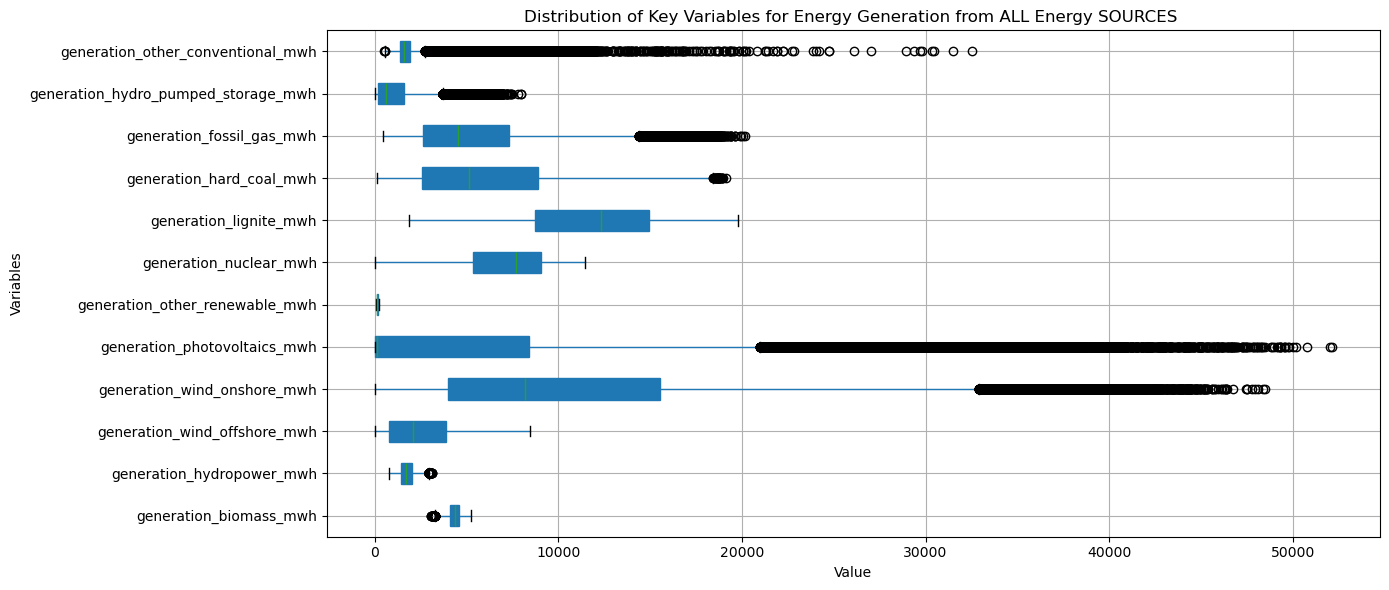

In [6]:
import matplotlib.pyplot as plt
key_vars = [
   "generation_biomass_mwh" , "generation_hydropower_mwh" , "generation_wind_offshore_mwh" , "generation_wind_onshore_mwh" , 
    "generation_photovoltaics_mwh" , "generation_other_renewable_mwh" , 
    "generation_nuclear_mwh" , "generation_lignite_mwh" , "generation_hard_coal_mwh" ,
    "generation_fossil_gas_mwh" , "generation_hydro_pumped_storage_mwh" , "generation_other_conventional_mwh" ]

plt.figure(figsize=(14, 6))

model_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Key Variables for Energy Generation from ALL Energy SOURCES ")
plt.xlabel("Value")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# BOXPLOT
## Distribution of Key Variables for Energy Generation from all Renewable Energy Resources  

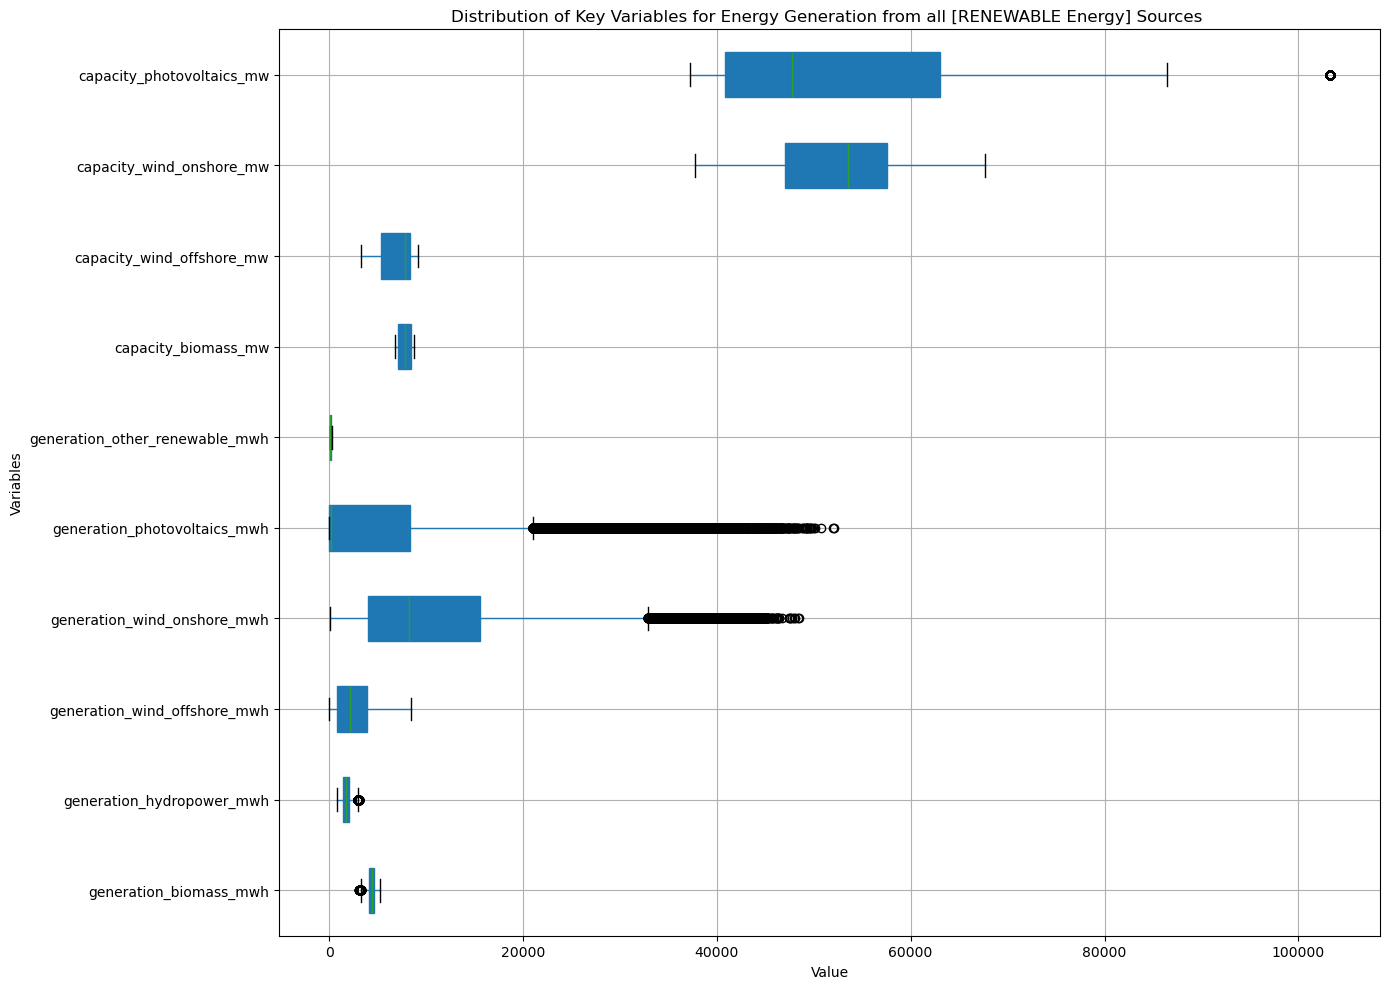

In [7]:
import matplotlib.pyplot as plt
key_vars = [
   "generation_biomass_mwh" , "generation_hydropower_mwh" , "generation_wind_offshore_mwh" , "generation_wind_onshore_mwh" , 
    "generation_photovoltaics_mwh" , "generation_other_renewable_mwh",
    "capacity_biomass_mw", "capacity_wind_offshore_mw", "capacity_wind_onshore_mw", "capacity_photovoltaics_mw"                 
    ]

plt.figure(figsize=(14, 10))

model_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Key Variables for Energy Generation from all [RENEWABLE Energy] Sources ")
plt.xlabel("Value")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# BOXPLOT
## Distribution of Key Variables for Energy Generation from all Conventional Energy Resources  

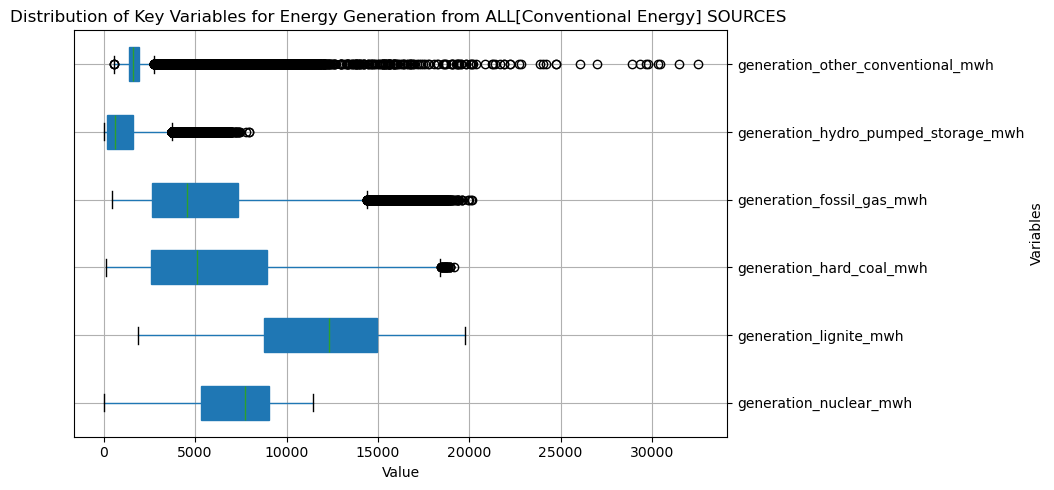

In [8]:
import matplotlib.pyplot as plt
key_vars = [
    "generation_nuclear_mwh" , "generation_lignite_mwh" , "generation_hard_coal_mwh" ,
    "generation_fossil_gas_mwh" , "generation_hydro_pumped_storage_mwh" , "generation_other_conventional_mwh" ]



import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

model_df[key_vars].boxplot(vert=False,     patch_artist=True
)

ax = plt.gca()

# Move y-axis label and tick labels to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

plt.ylabel("Variables")
plt.xlabel("Value")
plt.title("Distribution of Key Variables for Energy Generation from ALL[Conventional Energy] SOURCES ")

plt.tight_layout()
plt.show()

# BOXPLOT
## Distribution of Key Variables for Energy Consumption

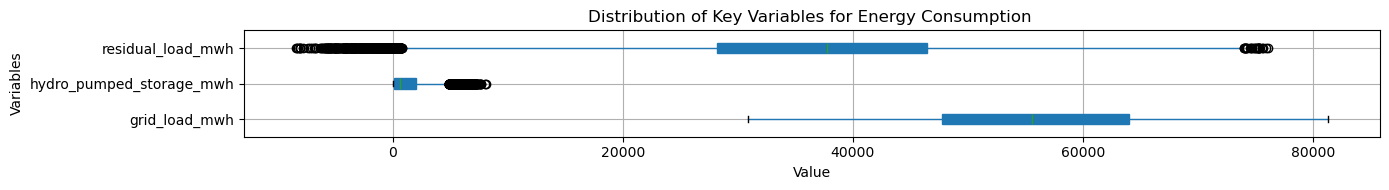

In [9]:
import matplotlib.pyplot as plt
key_vars = [
 "grid_load_mwh" , "hydro_pumped_storage_mwh" , "residual_load_mwh"    ]

plt.figure(figsize=(14, 2))

model_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Key Variables for Energy Consumption ")
plt.xlabel("Value")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# BOXPLOT
## Distribution of Key Variables for Solar Radiations

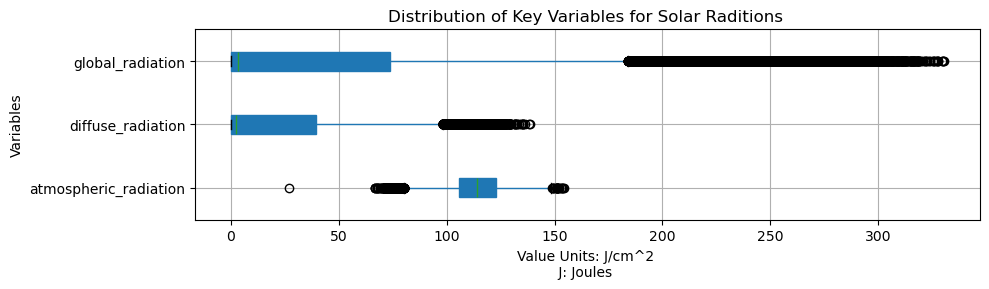

In [10]:
import matplotlib.pyplot as plt
key_vars = [
"atmospheric_radiation" , "diffuse_radiation" , "global_radiation"  ]

plt.figure(figsize=(10, 3))

model_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Key Variables for Solar Raditions ")
plt.xlabel("Value Units: J/cm^2 \n J: Joules  ")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# BOXPLOT
## Distribution of sunshine_duration

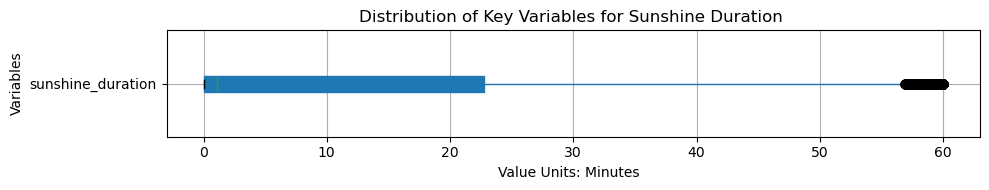

In [11]:
import matplotlib.pyplot as plt
key_vars = [
"sunshine_duration" ]

plt.figure(figsize=(10, 2))

model_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Key Variables for Sunshine Duration ")
plt.xlabel("Value Units: Minutes  ")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# BOXPLOT
## Distribution of solar Zenith angle

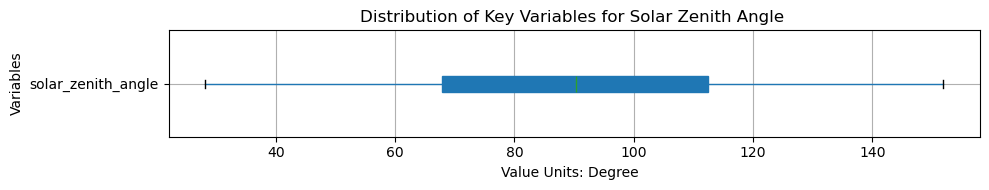

In [12]:
import matplotlib.pyplot as plt
key_vars = [
"solar_zenith_angle" ]

plt.figure(figsize=(10, 2))

model_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Key Variables for Solar Zenith Angle ")
plt.xlabel("Value Units: Degree  ")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# BOXPLOT
## Distribution of Wind key variables

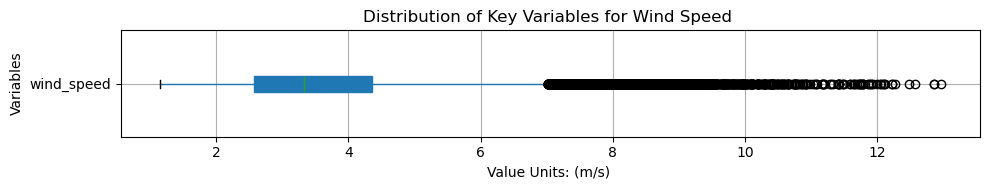

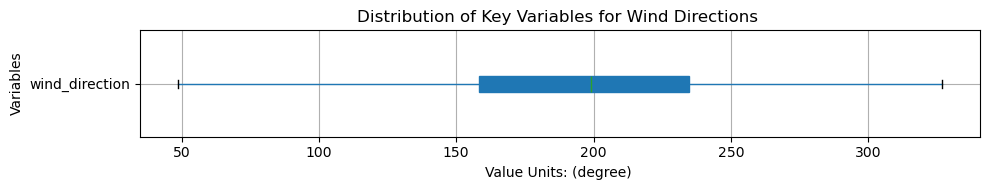

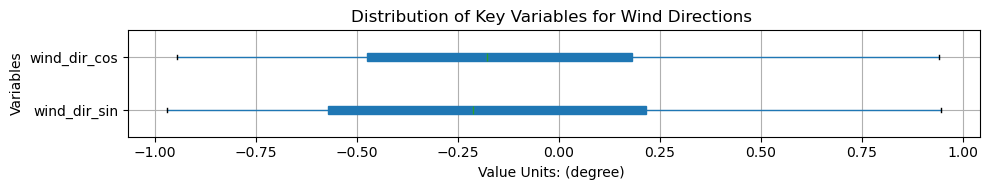

In [13]:
import matplotlib.pyplot as plt
key_vars = [
"wind_speed" ]

plt.figure(figsize=(10, 2))

model_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Key Variables for Wind Speed ")
plt.xlabel("Value Units: (m/s) ")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


#  Wind Directions
key_vars = [
"wind_direction"]

plt.figure(figsize=(10, 2))

model_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Key Variables for Wind Directions ")
plt.xlabel("Value Units: (degree) ")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

#  Wind Directions "wind_dir_sin" , "wind_dir_cos"
key_vars = [
"wind_dir_sin" , "wind_dir_cos"]

plt.figure(figsize=(10, 2))

model_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Key Variables for Wind Directions ")
plt.xlabel("Value Units: (degree) ")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# BOXPLOT
## Distribution Temperature and Humidity

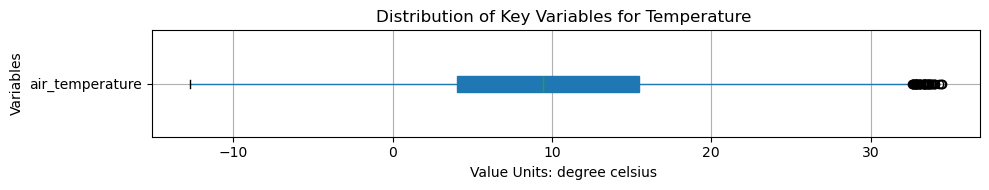

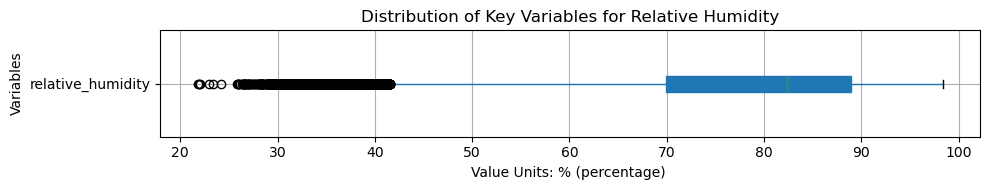

In [14]:

import matplotlib.pyplot as plt
key_vars = [
"air_temperature" ]

plt.figure(figsize=(10, 2))

model_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Key Variables for Temperature ")
plt.xlabel("Value Units: degree celsius ")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()



import matplotlib.pyplot as plt
key_vars = [
"relative_humidity" ]

plt.figure(figsize=(10, 2))

model_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Key Variables for Relative Humidity")
plt.xlabel("Value Units: % (percentage) ")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

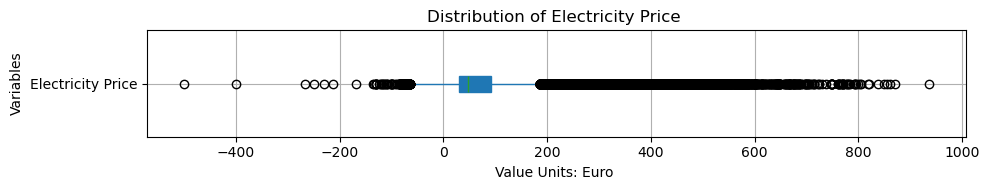

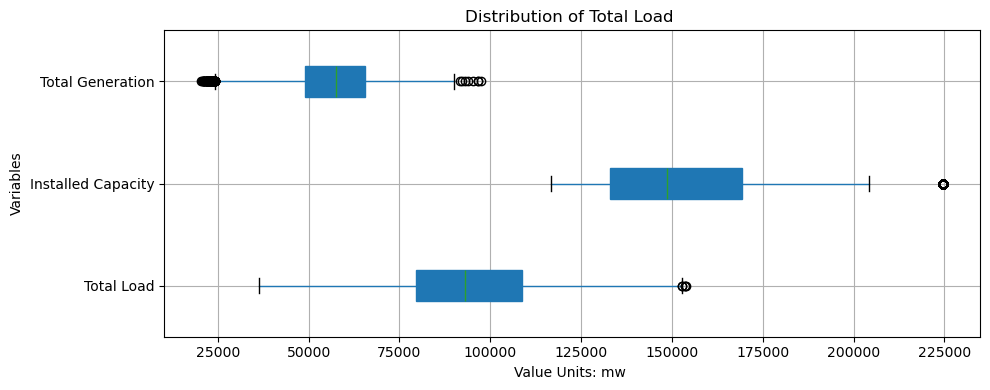

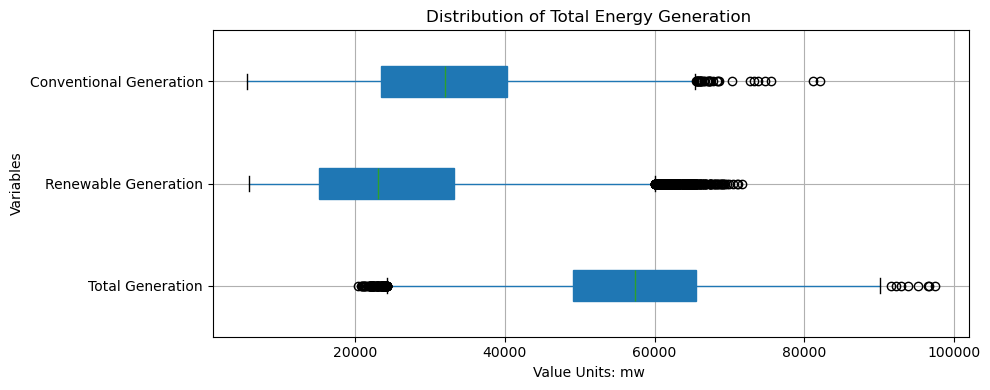

In [15]:
# tOTAL ENERGY generation
total_gen_cols = [
    "generation_biomass_mwh",
    "generation_hydropower_mwh",
    "generation_wind_offshore_mwh",
    "generation_wind_onshore_mwh",
    "generation_photovoltaics_mwh",
    "generation_other_renewable_mwh",
    "generation_nuclear_mwh",
    "generation_lignite_mwh",
    "generation_hard_coal_mwh",
    "generation_fossil_gas_mwh",
    "generation_hydro_pumped_storage_mwh",
    "generation_other_conventional_mwh"
]
# print(model_df[total_gen_cols].sum(axis=1).mean())
# Renewable generation
renewable_gen_cols = [
    "generation_biomass_mwh",
    "generation_hydropower_mwh",
    "generation_wind_offshore_mwh",
    "generation_wind_onshore_mwh",
    "generation_photovoltaics_mwh",
    "generation_other_renewable_mwh"
]

# Conventional generation
conventional_gen_cols = [
    "generation_nuclear_mwh",
    "generation_lignite_mwh",
    "generation_hard_coal_mwh",
    "generation_fossil_gas_mwh",
    "generation_hydro_pumped_storage_mwh",
    "generation_other_conventional_mwh"
]

# Load variables
load_cols = [
    "grid_load_mwh",
    "hydro_pumped_storage_mwh",
    "residual_load_mwh"
]

# Solar weather variables
solar_weather_cols = [
    "atmospheric_radiation",
    "diffuse_radiation",
    "global_radiation",
    "sunshine_duration",
    "solar_zenith_angle"
]

# Wind weather variables
wind_weather_cols = [
    "wind_speed",
    "wind_dir_sin",
    "wind_dir_cos",
    "wind_direction"
]

# Temperature variables
temp_cols = [
    "air_temperature",
    "relative_humidity"
]

# Capacity variables
capacity_cols = [
    "capacity_biomass_mw",
    "capacity_wind_offshore_mw",
    "capacity_wind_onshore_mw",
    "capacity_photovoltaics_mw",
    "capacity_fossil_gas_mw"
]

# Create aggregated features
plot_df = pd.DataFrame({
    "Total Generation": model_df[total_gen_cols].sum(axis=1),    
    "Renewable Generation": model_df[renewable_gen_cols].sum(axis=1),
    "Conventional Generation": model_df[conventional_gen_cols].sum(axis=1),
    "Total Load": model_df[load_cols].sum(axis=1),
    "Solar Variables": model_df[solar_weather_cols].sum(axis=1),
    "Wind Variables": model_df[wind_weather_cols].sum(axis=1),
    "Temperature Variables": model_df[temp_cols].sum(axis=1),
    "Installed Capacity": model_df[capacity_cols].sum(axis=1),
    "Electricity Price": model_df["price_eur_per_mwh"]
})


import matplotlib.pyplot as plt

# BOX PLOT FOR Electricity Price
key_vars = [
"Electricity Price" ]

plt.figure(figsize=(10, 2))

plot_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Electricity Price ")
plt.xlabel("Value Units: Euro ")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()







# BOX PLOT FOR Total Load 
key_vars = [
"Total Load", "Installed Capacity", "Total Generation" ]

plt.figure(figsize=(10, 4))

plot_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Total Load ")
plt.xlabel("Value Units: mw ")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()






# BOX PLOT FOR RENEWABLE ENERGY GENERATION 
key_vars = [
"Total Generation", "Renewable Generation", "Conventional Generation" ]

plt.figure(figsize=(10, 4))

plot_df[key_vars].boxplot(
    vert=False,
    patch_artist=True
)

plt.title("Distribution of Total Energy Generation ")
plt.xlabel("Value Units: mw ")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()







# Distribution Analysis

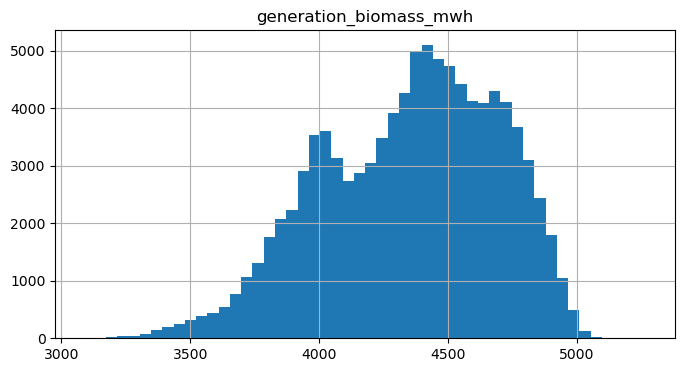

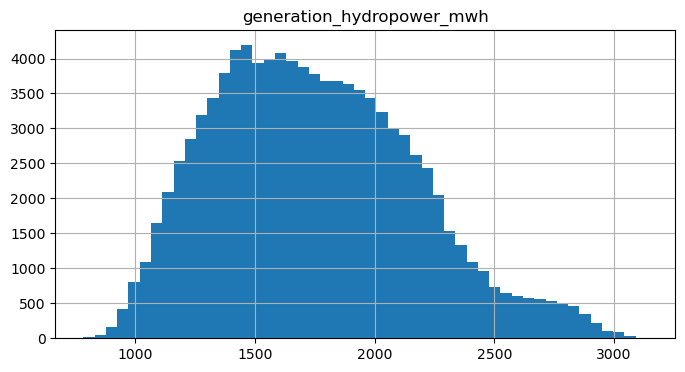

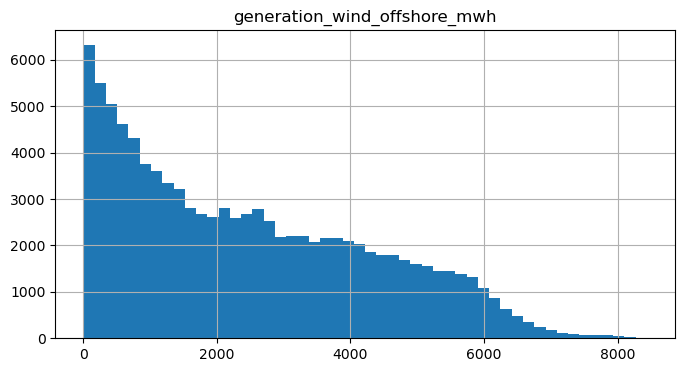

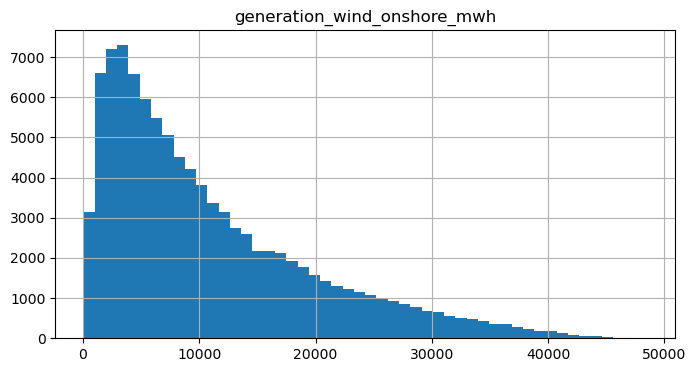

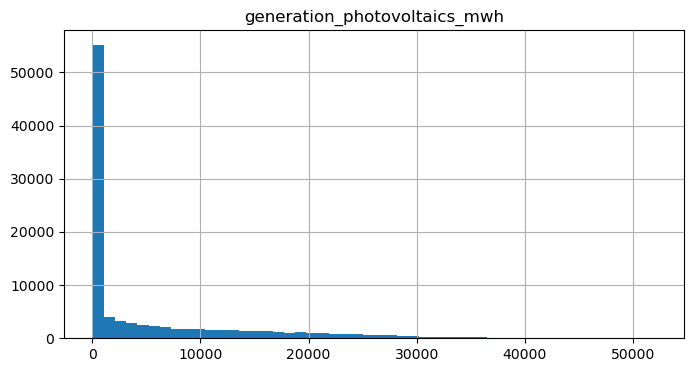

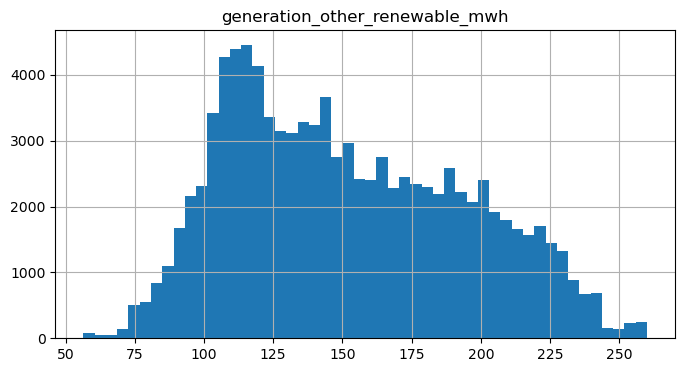

In [16]:
import matplotlib.pyplot as plt

targets = [
"generation_biomass_mwh" , "generation_hydropower_mwh" , "generation_wind_offshore_mwh" , "generation_wind_onshore_mwh" , "generation_photovoltaics_mwh" , "generation_other_renewable_mwh"

]

for col in targets:
    plt.figure(figsize=(8,4))
    model_df[col].hist(bins=50)
    plt.title(col)
    plt.show()

# Create Time Features

In [17]:
eda_df = model_df.copy()

eda_df["hour"] = eda_df["datetime"].dt.hour
eda_df["month"] = eda_df["datetime"].dt.month
eda_df["year"] = eda_df["datetime"].dt.year
eda_df["dayofweek"] = eda_df["datetime"].dt.dayofweek

      total_generation  renewable_generation  conventional_generation  \
year                                                                    
2015      5.389432e+08          1.615560e+08             3.773872e+08   
2016      5.413134e+08          1.711174e+08             3.701960e+08   
2017      5.104986e+08          1.961265e+08             3.143720e+08   
2018      5.422432e+08          2.067146e+08             3.355287e+08   
2019      5.213111e+08          2.232871e+08             2.980240e+08   
2020      5.035730e+08          2.332285e+08             2.703445e+08   
2021      5.112494e+08          2.143379e+08             2.969115e+08   
2022      4.999456e+08          2.332771e+08             2.666685e+08   
2023      4.535079e+08          2.515572e+08             2.019507e+08   
2024      4.376202e+08          2.561635e+08             1.814567e+08   
2025      4.378443e+08          2.577135e+08             1.801309e+08   
2026      1.260229e+08          6.649181e+07       

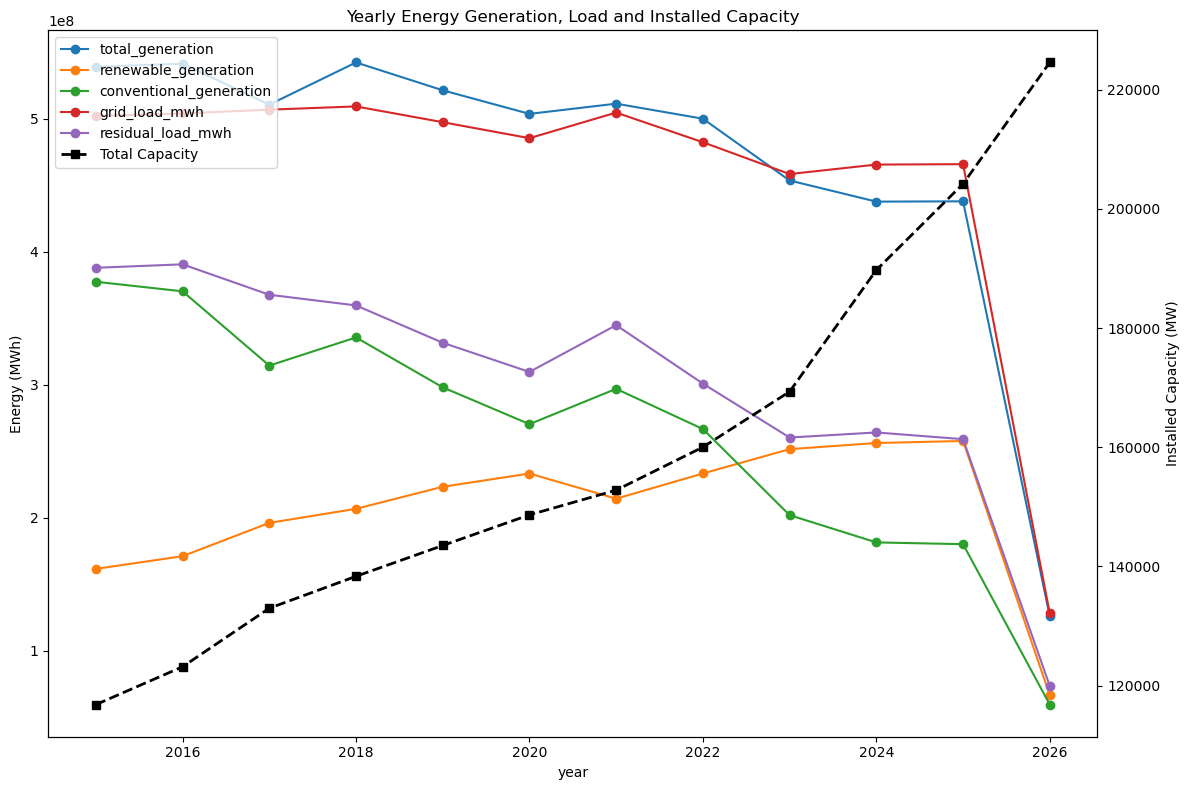

In [18]:
renewable_cols = [
    "generation_biomass_mwh",
    "generation_hydropower_mwh",
    "generation_wind_offshore_mwh",
    "generation_wind_onshore_mwh",
    "generation_photovoltaics_mwh",
    "generation_other_renewable_mwh"
]

conventional_cols = [
    "generation_nuclear_mwh",
    "generation_lignite_mwh",
    "generation_hard_coal_mwh",
    "generation_fossil_gas_mwh",
    "generation_hydro_pumped_storage_mwh",
    "generation_other_conventional_mwh"
]

capacity_cols = [
    "capacity_biomass_mw",
    "capacity_wind_offshore_mw",
    "capacity_wind_onshore_mw",
    "capacity_photovoltaics_mw",
    "capacity_fossil_gas_mw"
]

# Create aggregates
eda_df["renewable_generation"] = eda_df[renewable_cols].sum(axis=1)

eda_df["conventional_generation"] = eda_df[conventional_cols].sum(axis=1)

eda_df["total_generation"] = (
    eda_df["renewable_generation"]
    + eda_df["conventional_generation"]
)

eda_df["total_capacity"] = eda_df[capacity_cols].sum(axis=1)



################################ aggregate by year

yearly = (
    eda_df.groupby("year")
    .agg(
        {
            "total_generation": "sum",
            "renewable_generation": "sum",
            "conventional_generation": "sum",
            "grid_load_mwh": "sum",
            "residual_load_mwh" : "sum",
            "total_capacity": "mean"   # capacity should use mean, not sum
        }
    )
)

print(yearly)

###################################

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 8))

# MWh variables
yearly[
    [
        "total_generation",
        "renewable_generation",
        "conventional_generation",
        "grid_load_mwh",
        "residual_load_mwh"
    ]
].plot(ax=ax1, marker="o")

ax1.set_ylabel("Energy (MWh)")
ax1.set_title("Yearly Energy Generation, Load and Installed Capacity")

# Capacity on secondary axis
ax2 = ax1.twinx()

yearly["total_capacity"].plot(
    ax=ax2,
    color="black",
    linestyle="--",
    linewidth=2,
    marker="s",
    label="Total Capacity"
)

ax2.set_ylabel("Installed Capacity (MW)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Energy  Data Set over view and description

In [19]:
ed=eda_df[['grid_load_mwh','total_generation', 'renewable_generation', 'residual_load_mwh', 
           'conventional_generation', 'total_capacity' ]]

ed.describe()

,grid_load_mwh,total_generation,renewable_generation,residual_load_mwh,conventional_generation,total_capacity
count,98580.000000,98580.000000,98580.000000,98580.000000,98580.000000,98580.000000
mean,55882.754970,57050.850548,25071.728893,37019.061716,31979.121655,154261.247920
std,9943.769057,11495.565786,12004.296090,13701.618785,11808.057181,27418.165752
min,30902.750000,20375.250000,5788.500000,-8443.140000,5542.750000,116814.000000
25%,47752.215000,49038.437500,15205.687500,28193.012500,23473.187500,132983.000000
50%,55602.000000,57437.125000,22996.125000,37705.630000,31932.250000,148652.000000
75%,63963.705000,65549.062500,33134.812500,46469.500000,40282.812500,169331.000000
max,81319.500000,97474.000000,71742.000000,76034.380000,82056.250000,224569.000000


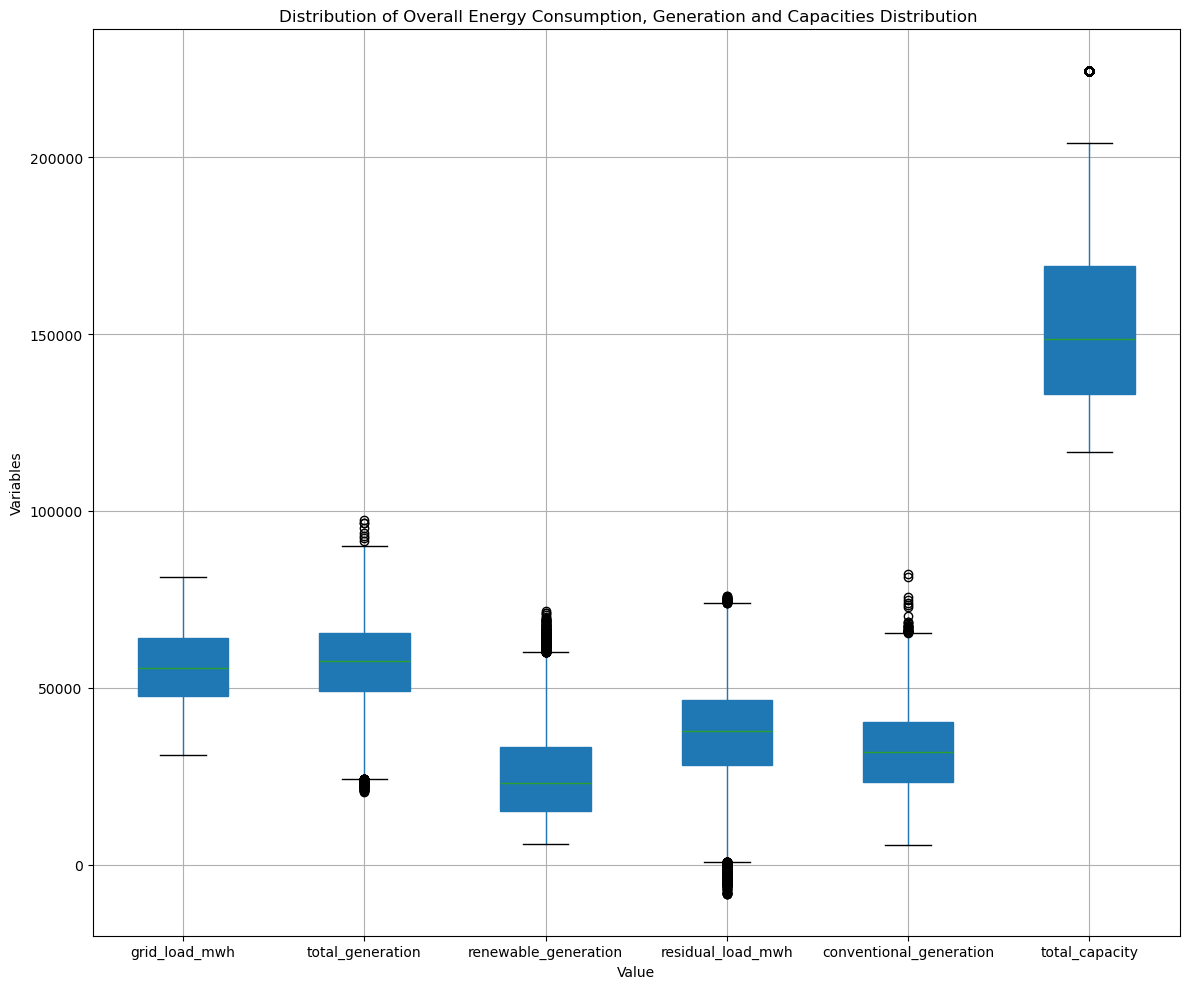

In [59]:
import matplotlib.pyplot as plt

key_vars = ['grid_load_mwh','total_generation', 'renewable_generation', 'residual_load_mwh' , 'conventional_generation', 'total_capacity'   ]

plt.figure(figsize=(12, 10))

eda_df[key_vars].boxplot(
    vert=True,
    patch_artist=True
)

plt.title("Distribution of Overall Energy Consumption, Generation and Capacities Distribution   ")
plt.xlabel("Value")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# Description of Energy generation by source type

In [21]:
ed=eda_df[['renewable_generation', 'generation_biomass_mwh', 'generation_hydropower_mwh','generation_wind_offshore_mwh',
           'generation_wind_onshore_mwh', 'generation_photovoltaics_mwh', 'generation_other_renewable_mwh' ]]

ed.describe()

,renewable_generation,generation_biomass_mwh,generation_hydropower_mwh,generation_wind_offshore_mwh,generation_wind_onshore_mwh,generation_photovoltaics_mwh,generation_other_renewable_mwh
count,98580.000000,98580.000000,98580.000000,98580.000000,98580.000000,98580.000000,98557.000000
mean,25071.728893,4351.209844,1750.075970,2452.882705,10888.026035,5477.915011,151.654711
std,12004.296090,342.267227,421.327285,1861.525593,8928.050400,8742.224860,42.224552
min,5788.500000,3085.630000,784.100000,0.000000,46.500000,0.000000,56.460000
25%,15205.687500,4088.500000,1426.000000,797.500000,3978.687500,0.500000,116.250000
50%,22996.125000,4389.750000,1713.250000,2116.500000,8199.475000,150.625000,145.250000
75%,33134.812500,4621.250000,2035.750000,3864.312500,15545.125000,8400.522500,184.750000
max,71742.000000,5271.250000,3138.000000,8441.730000,48499.500000,52132.250000,260.000000


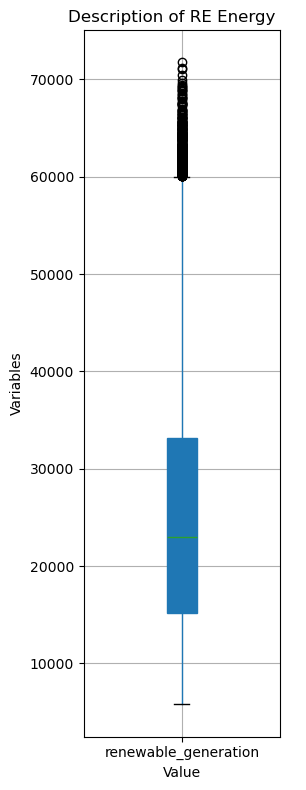

In [22]:
import matplotlib.pyplot as plt

key_vars = ['renewable_generation' ]

plt.figure(figsize=(3, 8))

eda_df[key_vars].boxplot(
    vert=True,
    patch_artist=True
)

plt.title("Description of RE Energy    ")
plt.xlabel("Value")
plt.ylabel("Variables")
plt.tight_layout()


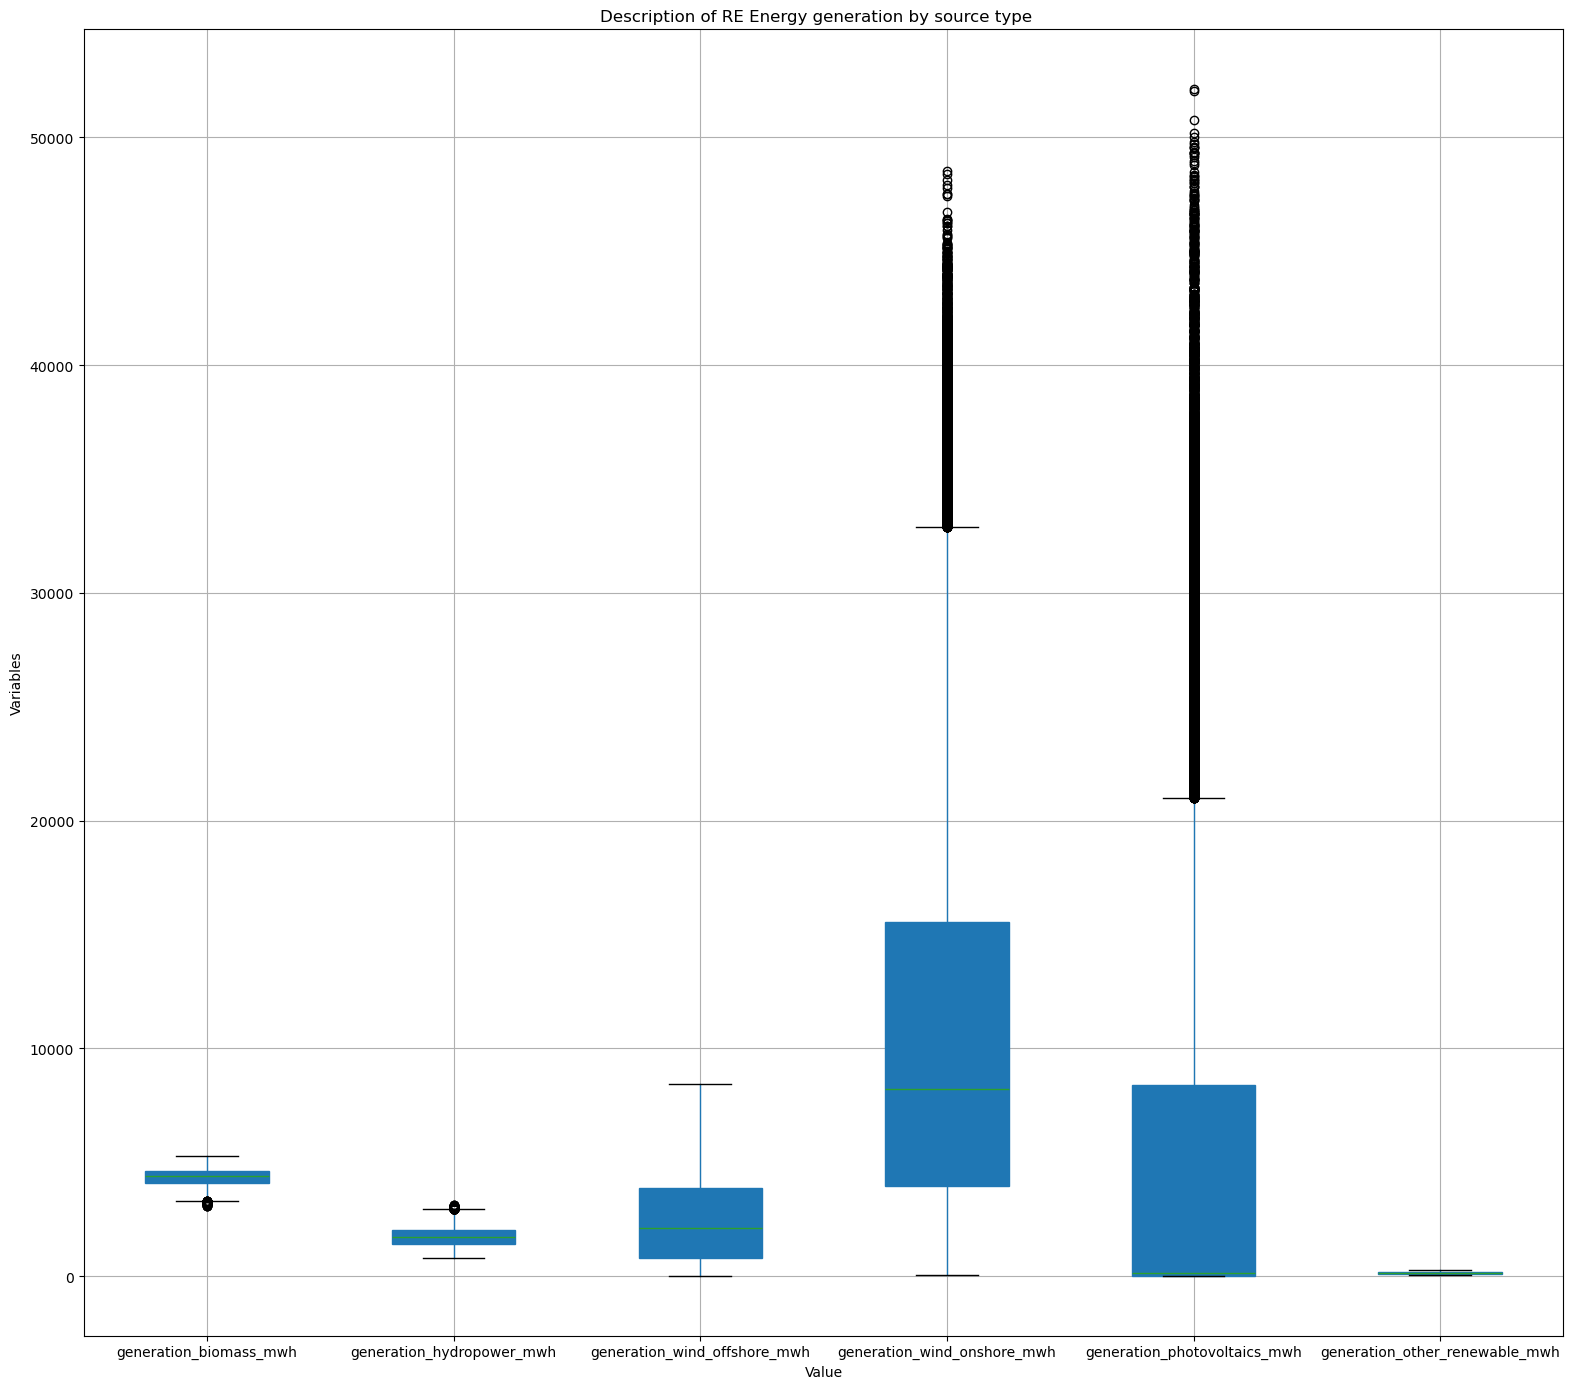

In [72]:
import matplotlib.pyplot as plt

key_vars = ['generation_biomass_mwh', 'generation_hydropower_mwh','generation_wind_offshore_mwh',
           'generation_wind_onshore_mwh', 'generation_photovoltaics_mwh', 'generation_other_renewable_mwh'   ]

plt.figure(figsize=(16, 14))

eda_df[key_vars].boxplot(
    vert=True,
    patch_artist=True
)

plt.title("Description of RE Energy generation by source type   ")
plt.xlabel("Value")
plt.ylabel("Variables")
plt.tight_layout()


# Weather Variables

In [24]:
ed=eda_df[['air_temperature', 'global_radiation', 'diffuse_radiation','sunshine_duration',
           'relative_humidity', 'wind_speed', 'wind_direction' ]]

ed.describe()

,air_temperature,global_radiation,diffuse_radiation,sunshine_duration,relative_humidity,wind_speed,wind_direction
count,98580.000000,98580.000000,98580.000000,98580.000000,98580.000000,98580.000000,98580.000000
mean,9.929339,46.989389,22.293866,12.634517,77.895997,3.626726,194.580589
std,7.505653,70.960207,30.387214,17.305675,14.413951,1.440395,52.152633
min,-12.742116,0.000000,0.000000,0.000000,21.775510,1.154093,48.794326
25%,4.027922,0.000000,0.000000,0.000000,69.981234,2.578405,158.420600
50%,9.410942,3.081667,2.481481,1.120000,82.320447,3.323132,198.931034
75%,15.458447,73.669643,39.308894,22.750000,88.945150,4.352143,234.893617
max,34.501020,330.657143,138.593750,60.000000,98.376754,12.962544,326.845878


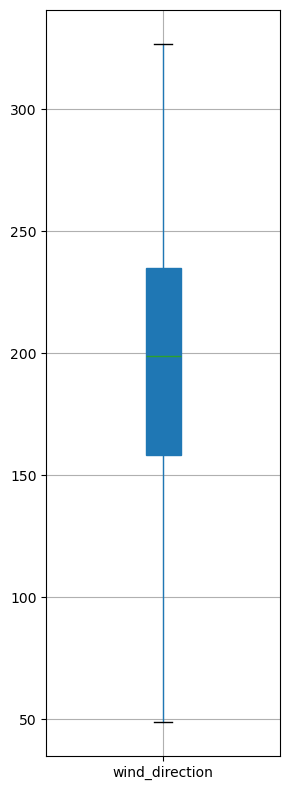

In [25]:
import matplotlib.pyplot as plt

key_vars = ['wind_direction'   ]

plt.figure(figsize=(3, 8))

eda_df[key_vars].boxplot(
    vert=True,
    patch_artist=True
)

# plt.title("Distribution of Weather Variables ")
# plt.xlabel("Value")
# plt.ylabel("Variables")
plt.tight_layout()


# Distribution of Capacities

In [26]:
eda_df.columns

Index(['datetime', 'generation_biomass_mwh', 'generation_hydropower_mwh',
       'generation_wind_offshore_mwh', 'generation_wind_onshore_mwh',
       'generation_photovoltaics_mwh', 'generation_other_renewable_mwh',
       'generation_nuclear_mwh', 'generation_lignite_mwh',
       'generation_hard_coal_mwh', 'generation_fossil_gas_mwh',
       'generation_hydro_pumped_storage_mwh',
       'generation_other_conventional_mwh', 'grid_load_mwh',
       'hydro_pumped_storage_mwh', 'residual_load_mwh',
       'atmospheric_radiation', 'diffuse_radiation', 'global_radiation',
       'sunshine_duration', 'solar_zenith_angle', 'wind_speed', 'wind_dir_sin',
       'wind_dir_cos', 'wind_direction', 'air_temperature',
       'relative_humidity', 'capacity_biomass_mw', 'capacity_wind_offshore_mw',
       'capacity_wind_onshore_mw', 'capacity_photovoltaics_mw',
       'capacity_fossil_gas_mw', 'price_eur_per_mwh', 'year', 'hour', 'month',
       'dayofweek', 'renewable_generation', 'conventional_gen

In [27]:
ed=eda_df[['total_capacity', 'capacity_biomass_mw', 'capacity_wind_offshore_mw','capacity_wind_onshore_mw',
           'capacity_photovoltaics_mw' ]]

ed.describe()

,total_capacity,capacity_biomass_mw,capacity_wind_offshore_mw,capacity_wind_onshore_mw,capacity_photovoltaics_mw
count,98580.000000,98580.000000,98580.000000,98580.000000,98580.000000
mean,154261.247920,7810.116799,7046.018127,52498.654971,54333.986103
std,27418.165752,709.927633,1841.948628,7551.440563,16916.117979
min,116814.000000,6808.000000,3300.000000,37701.000000,37271.000000
25%,132983.000000,7073.000000,5400.000000,47042.000000,40834.000000
50%,148652.000000,7833.000000,7800.000000,53553.000000,47754.000000
75%,169331.000000,8467.000000,8400.000000,57590.000000,63066.000000
max,224569.000000,8771.000000,9226.000000,67693.000000,103260.000000


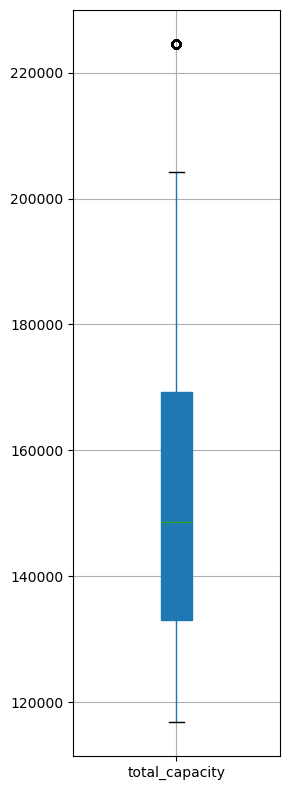

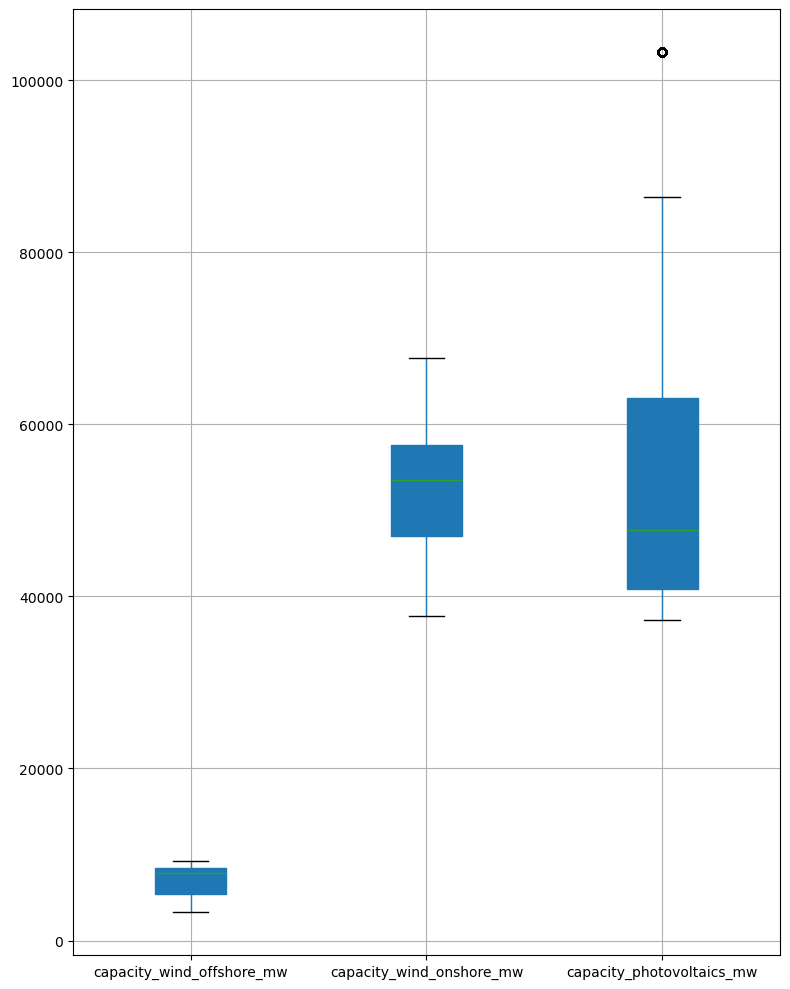

In [68]:
import matplotlib.pyplot as plt
key_vars = ['total_capacity'  ]

plt.figure(figsize=(3, 8))

eda_df[key_vars].boxplot(
    vert=True,
    patch_artist=True
)

# plt.title("Distribution of Weather Variables ")
# plt.xlabel("Value")
# plt.ylabel("Variables")
plt.tight_layout()


key_vars = ['capacity_biomass_mw', 'capacity_wind_offshore_mw','capacity_wind_onshore_mw',
           'capacity_photovoltaics_mw'  ]

plt.figure(figsize=(10, 8))

eda_df[key_vars].boxplot(
    vert=True,
    patch_artist=True
)

# plt.title("Distribution of Weather Variables ")
# plt.xlabel("Value")
# plt.ylabel("Variables")
plt.tight_layout()


___________________________________________________________________________________________________ 
__________________________________________________________________________________________________ 
____________________________________________________________________________________________________
_____________________________________________________________________________________________________
______________________________________________________________________________________________________ 

In [29]:
yearly

,total_generation,renewable_generation,conventional_generation,grid_load_mwh,residual_load_mwh,total_capacity
year,,,,,,
2015,5.389432e+08,1.615560e+08,3.773872e+08,5.019522e+08,3.878939e+08,116814.0
2016,5.413134e+08,1.711174e+08,3.701960e+08,5.038829e+08,3.904906e+08,123167.0
2017,5.104986e+08,1.961265e+08,3.143720e+08,5.067493e+08,3.676169e+08,132983.0
2018,5.422432e+08,2.067146e+08,3.355287e+08,5.091837e+08,3.596101e+08,138342.0
2019,5.213111e+08,2.232871e+08,2.980240e+08,4.973261e+08,3.315405e+08,143514.0
2020,5.035730e+08,2.332285e+08,2.703445e+08,4.853155e+08,3.095948e+08,148652.0
2021,5.112494e+08,2.143379e+08,2.969115e+08,5.045600e+08,3.447721e+08,152801.0
2022,4.999456e+08,2.332771e+08,2.666685e+08,4.822609e+08,3.008116e+08,160018.0
2023,4.535079e+08,2.515572e+08,2.019507e+08,4.583443e+08,2.603019e+08,169331.0


# Yearly Generation Patterns

      generation_biomass_mwh  generation_hydropower_mwh  \
year                                                      
2015             3978.071041                1566.170325   
2016             4524.761371                2057.883183   
2017             4603.721658                1779.758291   
2018             4576.352209                1774.271949   
2019             4506.695413                1880.341863   
2020             4549.905770                1815.329087   
2021             4364.758748                1699.676361   
2022             4308.041671                1461.713224   
2023             4257.482375                1714.631921   
2024             4120.828646                1998.206450   
2025             4095.246784                1619.081116   
2026             4258.118106                1271.636647   

      generation_wind_offshore_mwh  generation_wind_onshore_mwh  \
year                                                              
2015                    928.519309     

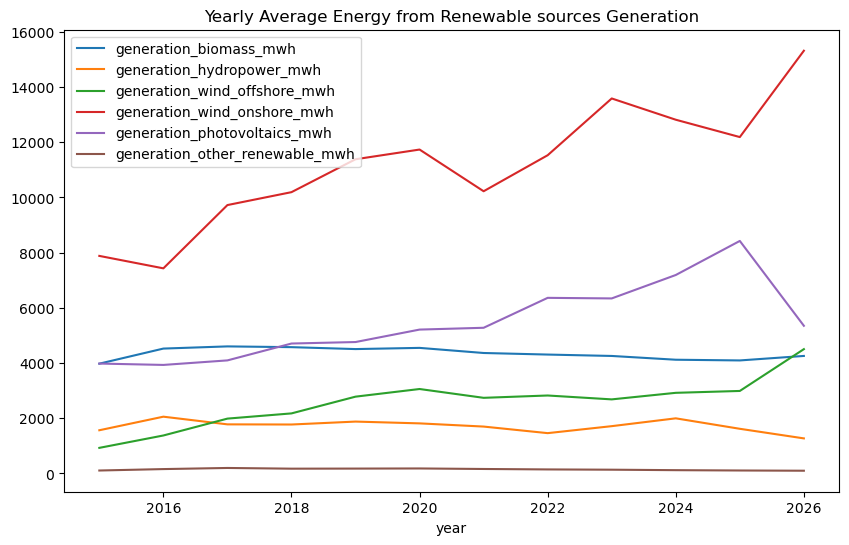

      generation_nuclear_mwh  generation_lignite_mwh  \
year                                                   
2015             9630.426647            15273.550648   
2016             9135.000171            14842.449633   
2017             8243.878168            14759.810966   
2018             8201.124129            14649.411862   
2019             8109.997645            11727.789459   
2020             6935.816478             9492.167739   
2021             7466.461040            11210.540744   
2022             3747.160050            11818.061836   
2023              769.578633             8886.923935   
2024                0.000000             8081.319936   
2025                     NaN             7667.875082   
2026                     NaN             9322.238555   

      generation_hard_coal_mwh  generation_fossil_gas_mwh  \
year                                                        
2015               9263.004181                1738.194885   
2016               9209.324917  

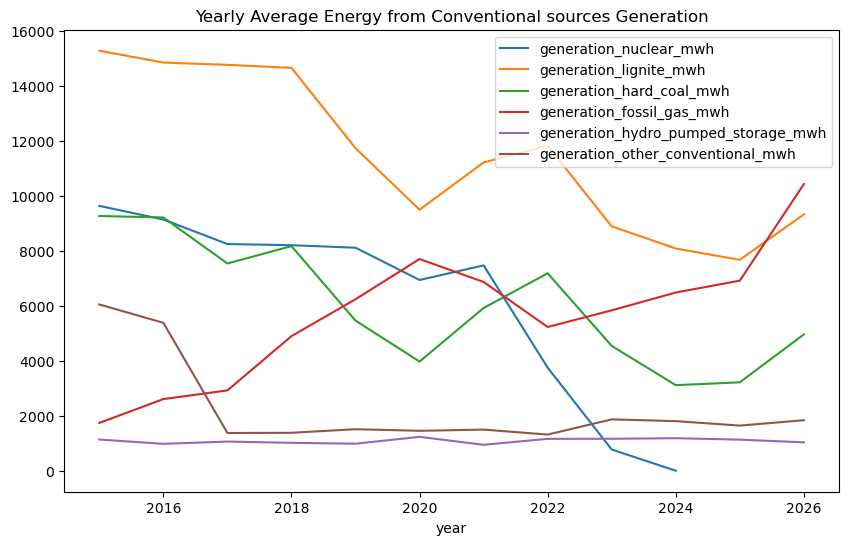

      capacity_biomass_mw  capacity_wind_offshore_mw  \
year                                                   
2015               6808.0                     3300.0   
2016               6815.0                     4100.0   
2017               7080.0                     5400.0   
2018               7073.0                     6600.0   
2019               7720.0                     7700.0   
2020               7833.0                     7800.0   
2021               8204.0                     7900.0   
2022               8332.0                     8100.0   
2023               8467.0                     8400.0   
2024               8577.0                     8456.0   
2025               8766.0                     9215.0   
2026               8771.0                     9226.0   

      capacity_wind_onshore_mw  capacity_photovoltaics_mw  \
year                                                        
2015                   37701.0                    37271.0   
2016                   41168.0  

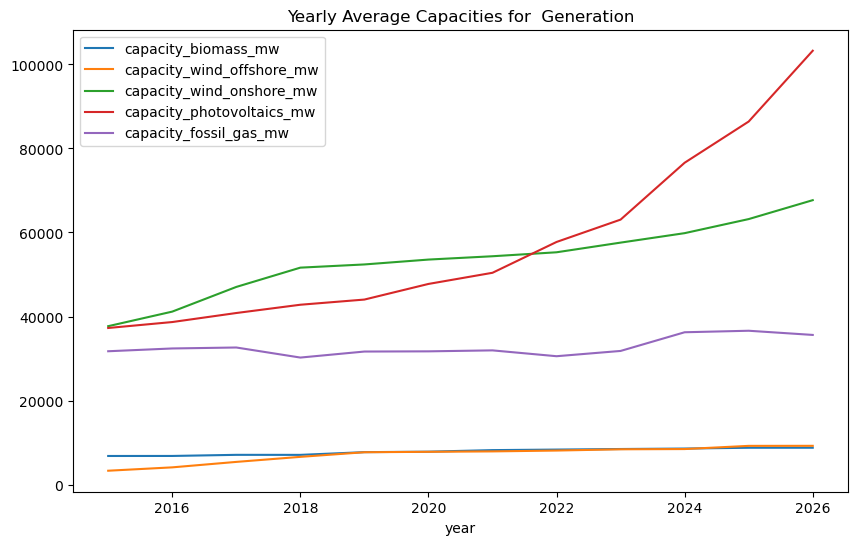

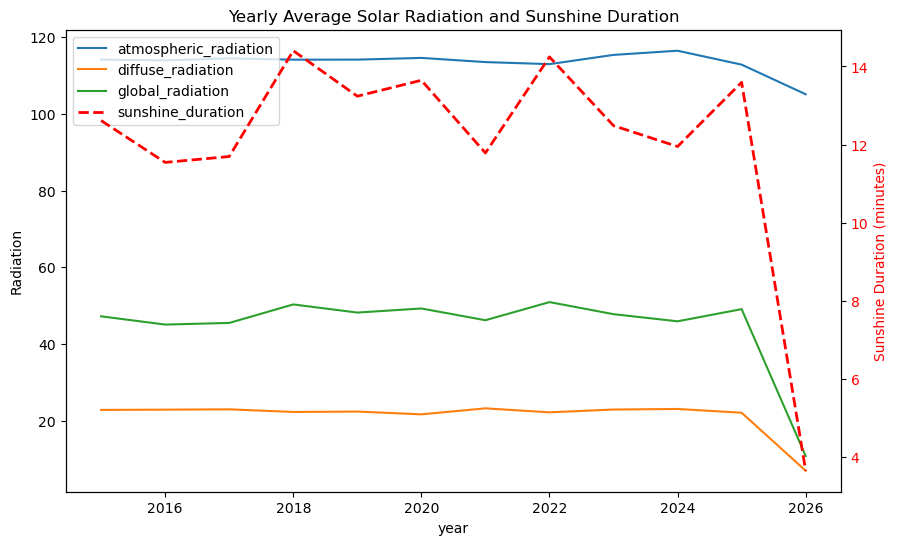

In [30]:
year = eda_df.groupby("year")[
    [
"generation_biomass_mwh" , "generation_hydropower_mwh" , "generation_wind_offshore_mwh" , "generation_wind_onshore_mwh" , "generation_photovoltaics_mwh",
         "generation_other_renewable_mwh"

    ]
].mean()

print(year)
year.plot(figsize=(10,6))
plt.title("Yearly Average Energy from Renewable sources Generation")
plt.show()

year = eda_df.groupby("year")[
    [
"generation_nuclear_mwh" , "generation_lignite_mwh" , "generation_hard_coal_mwh" , "generation_fossil_gas_mwh" , 
        "generation_hydro_pumped_storage_mwh" , "generation_other_conventional_mwh"


    ]
].mean()

print(year)
year.plot(figsize=(10,6))
plt.title("Yearly Average Energy from Conventional sources Generation")
plt.show()

year = eda_df.groupby("year")[
    [
 "capacity_biomass_mw" , "capacity_wind_offshore_mw" , "capacity_wind_onshore_mw" , "capacity_photovoltaics_mw" , "capacity_fossil_gas_mw", 

    ]
].mean()

print(year)
year.plot(figsize=(10,6))
plt.title("Yearly Average Capacities for  Generation")
plt.show()
######################################################
import matplotlib.pyplot as plt

year = eda_df.groupby("year")[
    [
        "atmospheric_radiation",
        "diffuse_radiation",
        "global_radiation",
        "sunshine_duration"
    ]
].mean()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Radiation variables
year[
    [
        "atmospheric_radiation",
        "diffuse_radiation",
        "global_radiation"
    ]
].plot(ax=ax1)

ax1.set_ylabel("Radiation")
ax1.set_title("Yearly Average Solar Radiation and Sunshine Duration")

# Sunshine duration on secondary axis (red)
ax2 = ax1.twinx()
year["sunshine_duration"].plot(
    ax=ax2,
    color="red",
    linestyle="--",
    linewidth=2,
    label="sunshine_duration"
)

ax2.set_ylabel("Sunshine Duration (minutes)", color="red")
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.show()

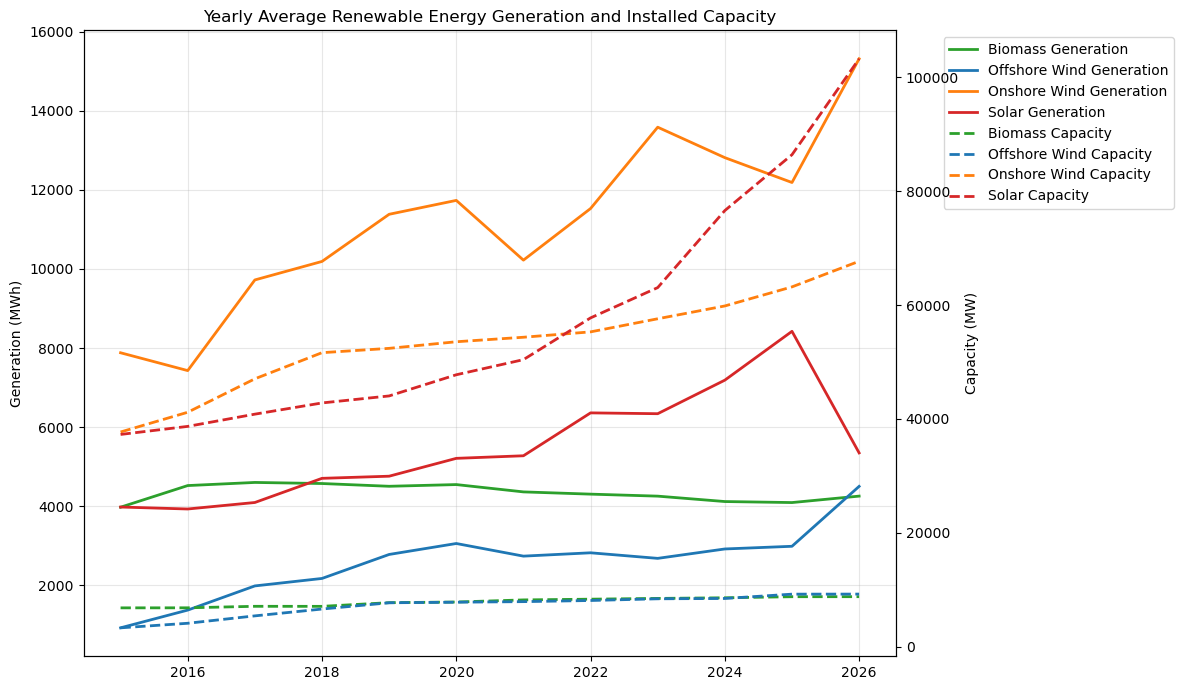

In [31]:
import matplotlib.pyplot as plt

# ---------------------------------------------------
# YEARLY AVERAGE GENERATION
# ---------------------------------------------------
generation_year = eda_df.groupby("year")[
    [
        "generation_biomass_mwh",
        "generation_wind_offshore_mwh",
        "generation_wind_onshore_mwh",
        "generation_photovoltaics_mwh"
    ]
].mean()

# ---------------------------------------------------
# YEARLY AVERAGE CAPACITY
# ---------------------------------------------------
capacity_year = eda_df.groupby("year")[
    [
        "capacity_biomass_mw",
        "capacity_wind_offshore_mw",
        "capacity_wind_onshore_mw",
        "capacity_photovoltaics_mw"
    ]
].mean()

# ---------------------------------------------------
# PLOT
# ---------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12, 7))

# Define matching colors
colors = {
    "biomass": "tab:green",
    "wind_offshore": "tab:blue",
    "wind_onshore": "tab:orange",
    "photovoltaics": "tab:red"
}

# ---- Generation (solid lines) ----
ax1.plot(
    generation_year.index,
    generation_year["generation_biomass_mwh"],
    color=colors["biomass"],
    linestyle="-",
    linewidth=2,
    label="Biomass Generation"
)

ax1.plot(
    generation_year.index,
    generation_year["generation_wind_offshore_mwh"],
    color=colors["wind_offshore"],
    linestyle="-",
    linewidth=2,
    label="Offshore Wind Generation"
)

ax1.plot(
    generation_year.index,
    generation_year["generation_wind_onshore_mwh"],
    color=colors["wind_onshore"],
    linestyle="-",
    linewidth=2,
    label="Onshore Wind Generation"
)

ax1.plot(
    generation_year.index,
    generation_year["generation_photovoltaics_mwh"],
    color=colors["photovoltaics"],
    linestyle="-",
    linewidth=2,
    label="Solar Generation"
)

ax1.set_ylabel("Generation (MWh)")

# ---- Capacity (dotted lines on secondary axis) ----
ax2 = ax1.twinx()

ax2.plot(
    capacity_year.index,
    capacity_year["capacity_biomass_mw"],
    color=colors["biomass"],
    linestyle="--",
    linewidth=2,
    label="Biomass Capacity"
)

ax2.plot(
    capacity_year.index,
    capacity_year["capacity_wind_offshore_mw"],
    color=colors["wind_offshore"],
    linestyle="--",
    linewidth=2,
    label="Offshore Wind Capacity"
)

ax2.plot(
    capacity_year.index,
    capacity_year["capacity_wind_onshore_mw"],
    color=colors["wind_onshore"],
    linestyle="--",
    linewidth=2,
    label="Onshore Wind Capacity"
)

ax2.plot(
    capacity_year.index,
    capacity_year["capacity_photovoltaics_mw"],
    color=colors["photovoltaics"],
    linestyle="--",
    linewidth=2,
    label="Solar Capacity"
)

ax2.set_ylabel("Capacity (MW)")

# ---- Combined Legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("Yearly Average Renewable Energy Generation and Installed Capacity")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Monthly Generation Patterns

       total_generation  renewable_generation  conventional_generation  \
month                                                                    
1          63540.813088          26262.486779             37278.326309   
2          63779.607162          27505.489860             36274.117302   
3          59537.718657          26384.394897             33153.323761   
4          55100.230745          25987.982102             29112.248643   
5          51167.134164          25581.074047             25586.060117   
6          52085.160859          24526.534943             27558.625915   
7          52659.898390          24103.663785             28556.234604   
8          51594.099993          22573.133076             29020.966917   
9          54715.318106          23012.083763             31703.234343   
10         57801.598134          24889.547033             32912.051101   
11         61274.316739          23801.639708             37472.677030   
12         60419.140639          25925

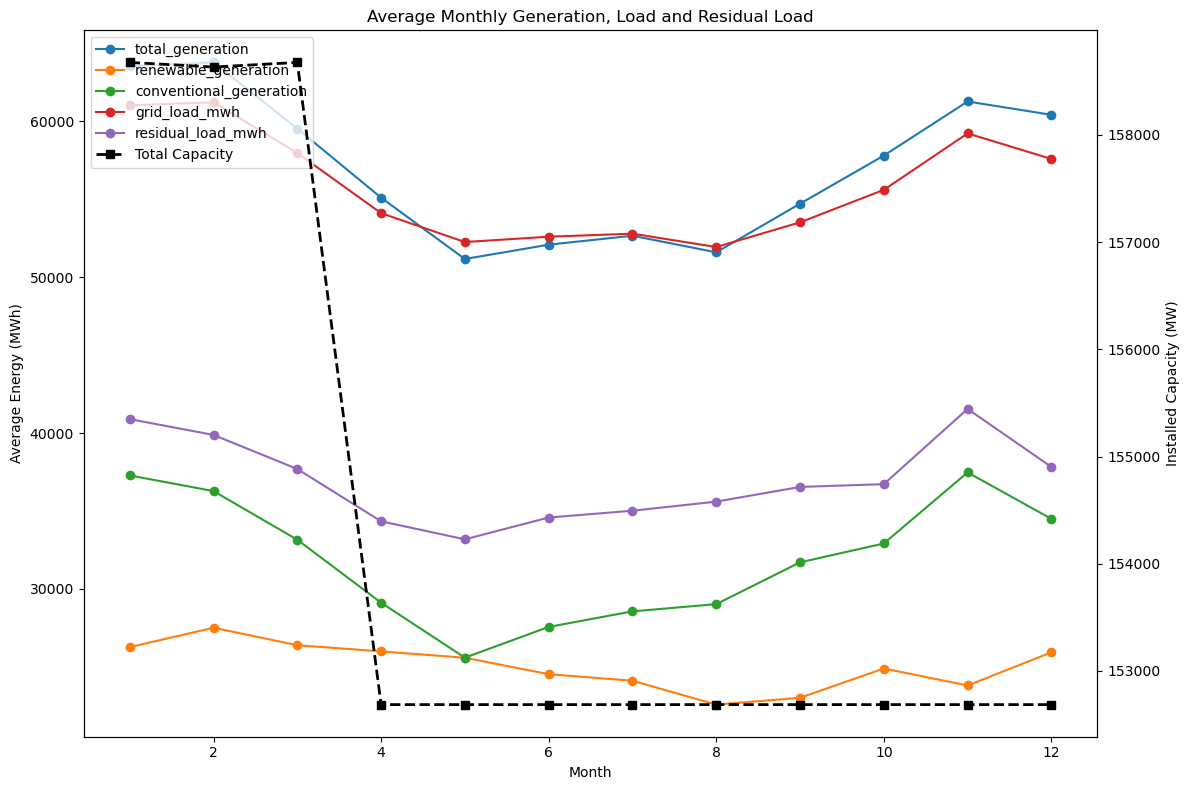

In [32]:
# ---------------------------------------------------
# MONTHLY AGGREGATES
# ---------------------------------------------------

monthly = (
    eda_df.groupby("month")
    .agg(
        {
            "total_generation": "mean",
            "renewable_generation": "mean",
            "conventional_generation": "mean",
            "grid_load_mwh": "mean",
            "residual_load_mwh": "mean",
            "total_capacity": "mean"
        }
    )
)

print(monthly)
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 8))

# Energy variables
monthly[
    [
        "total_generation",
        "renewable_generation",
        "conventional_generation",
        "grid_load_mwh",
        "residual_load_mwh"
    ]
].plot(ax=ax1, marker="o")

ax1.set_ylabel("Average Energy (MWh)")
ax1.set_xlabel("Month")
ax1.set_title(
    "Average Monthly Generation, Load and Residual Load"
)

# Capacity on secondary axis
ax2 = ax1.twinx()

monthly["total_capacity"].plot(
    ax=ax2,
    color="black",
    linestyle="--",
    linewidth=2,
    marker="s",
    label="Total Capacity"
)

ax2.set_ylabel("Installed Capacity (MW)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [33]:
monthly

,total_generation,renewable_generation,conventional_generation,grid_load_mwh,residual_load_mwh,total_capacity
month,,,,,,
1,63540.813088,26262.486779,37278.326309,61027.532919,40892.778894,158676.333333
2,63779.607162,27505.489860,36274.117302,61219.141450,39877.926892,158633.619469
3,59537.718657,26384.394897,33153.323761,57966.472054,37691.030852,158676.333333
4,55100.230745,25987.982102,29112.248643,54108.913817,34335.639720,152686.090909
5,51167.134164,25581.074047,25586.060117,52256.275307,33179.164490,152686.090909
6,52085.160859,24526.534943,27558.625915,52597.422923,34577.034301,152686.090909
7,52659.898390,24103.663785,28556.234604,52791.326045,35015.435718,152686.090909
8,51594.099993,22573.133076,29020.966917,51935.737168,35598.113678,152686.090909
9,54715.318106,23012.083763,31703.234343,53518.445982,36541.492145,152686.090909


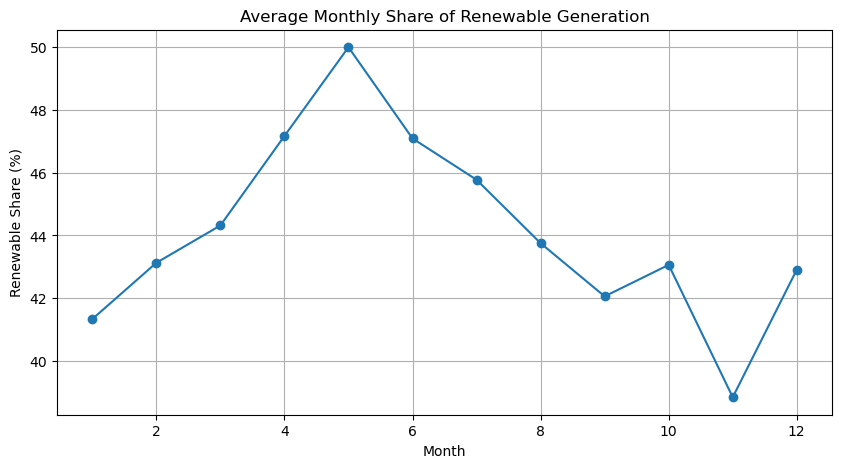

In [34]:
monthly["renewable_share"] = (
    monthly["renewable_generation"]
    / monthly["total_generation"]
) * 100

plt.figure(figsize=(10,5))

monthly["renewable_share"].plot(
    marker="o"
)

plt.ylabel("Renewable Share (%)")
plt.xlabel("Month")
plt.title(
    "Average Monthly Share of Renewable Generation"
)

plt.grid(True)
plt.show()

       generation_biomass_mwh  generation_hydropower_mwh  \
month                                                      
1                 4520.424420                1503.158762   
2                 4554.597321                1513.719157   
3                 4491.010873                1532.755247   
4                 4426.849053                1690.569571   
5                 4346.388349                2065.531342   
6                 4187.568908                2217.970486   
7                 4108.521746                2117.905975   
8                 4105.525700                2017.422600   
9                 4111.890218                1806.439298   
10                4304.679910                1587.051237   
11                4460.568635                1521.065158   
12                4562.767495                1475.425886   

       generation_wind_offshore_mwh  generation_wind_onshore_mwh  \
month                                                              
1                      

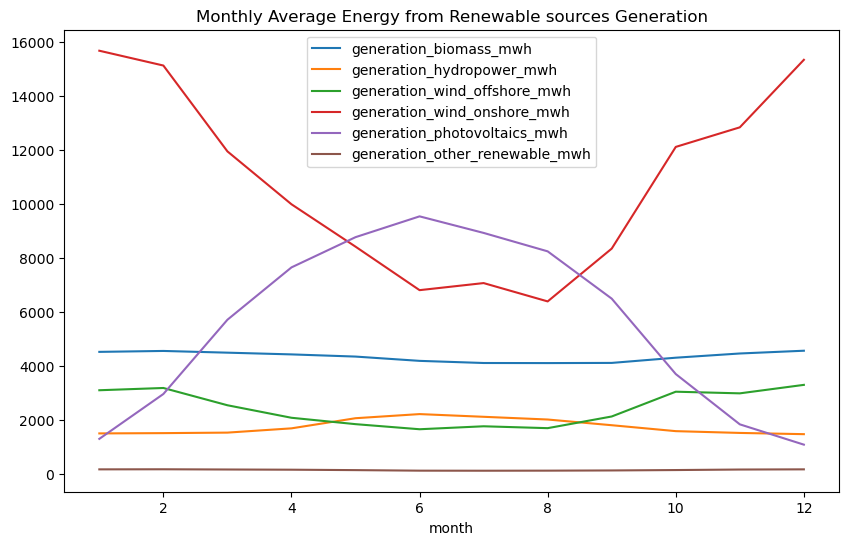

       generation_nuclear_mwh  generation_lignite_mwh  \
month                                                   
1                 6973.096806            12516.635317   
2                 7654.171506            12305.463201   
3                 7290.373037            11827.502673   
4                 6378.027932            11017.354672   
5                 5784.636275             9903.209036   
6                 6268.316319            10723.665436   
7                 6098.933206            11020.137005   
8                 7094.123581            11229.935576   
9                 7030.438889            11832.062437   
10                7086.143631            12255.231152   
11                7376.787114            13132.980942   
12                7268.672640            11605.077213   

       generation_hard_coal_mwh  generation_fossil_gas_mwh  \
month                                                        
1                   7958.531511                7463.928980   
2              

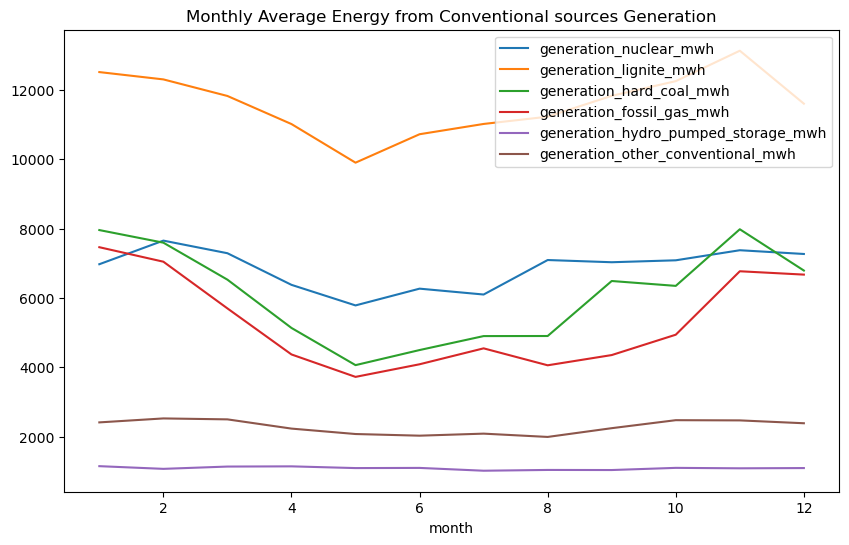

       capacity_biomass_mw  capacity_wind_offshore_mw  \
month                                                   
1              7870.500000                7183.083333   
2              7869.359882                7179.563422   
3              7870.500000                7183.083333   
4              7788.636364                6997.363636   
5              7788.636364                6997.363636   
6              7788.636364                6997.363636   
7              7788.636364                6997.363636   
8              7788.636364                6997.363636   
9              7788.636364                6997.363636   
10             7788.636364                6997.363636   
11             7788.636364                6997.363636   
12             7788.636364                6997.363636   

       capacity_wind_onshore_mw  capacity_photovoltaics_mw  \
month                                                        
1                  53453.416667               57406.166667   
2              

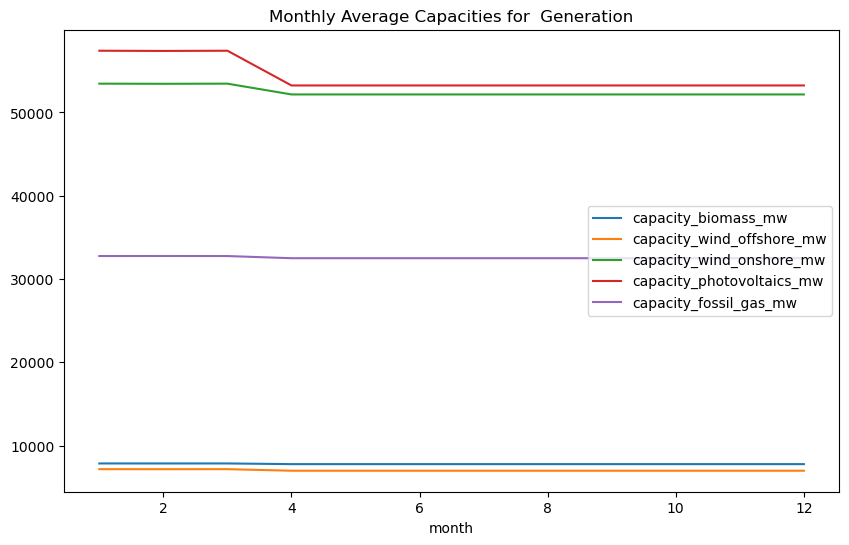

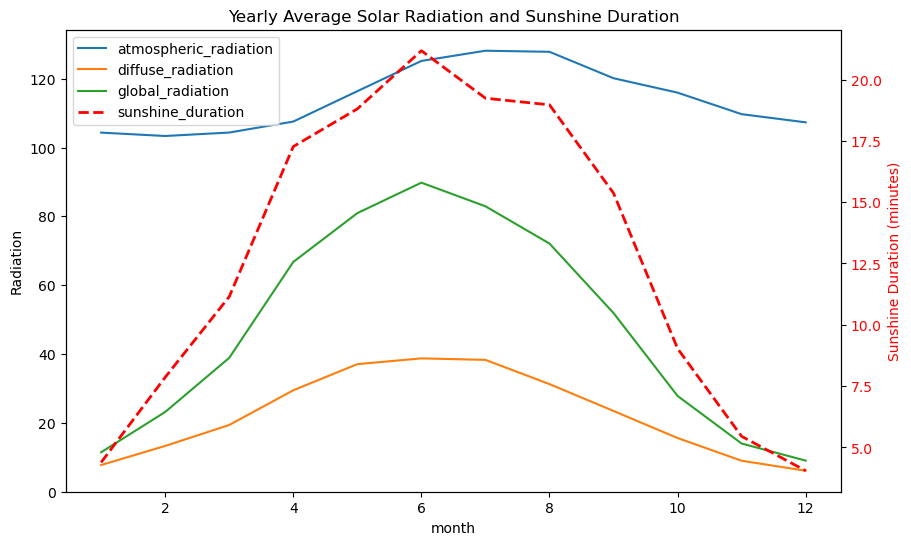

In [35]:
month = eda_df.groupby("month")[
    [
"generation_biomass_mwh" , "generation_hydropower_mwh" , "generation_wind_offshore_mwh" , "generation_wind_onshore_mwh" , "generation_photovoltaics_mwh",
         "generation_other_renewable_mwh"

    ]
].mean()

print(month)
month.plot(figsize=(10,6))
plt.title("Monthly Average Energy from Renewable sources Generation")
plt.show()
############################################
month = eda_df.groupby("month")[
    [
"generation_nuclear_mwh" , "generation_lignite_mwh" , "generation_hard_coal_mwh" , "generation_fossil_gas_mwh" , 
        "generation_hydro_pumped_storage_mwh" , "generation_other_conventional_mwh"


    ]
].mean()

print(month)
month.plot(figsize=(10,6))
plt.title("Monthly Average Energy from Conventional sources Generation")
plt.show()
#################################################
month = eda_df.groupby("month")[
    [
 "capacity_biomass_mw" , "capacity_wind_offshore_mw" , "capacity_wind_onshore_mw" , "capacity_photovoltaics_mw" , "capacity_fossil_gas_mw", 

    ]
].mean()

print(month)
month.plot(figsize=(10,6))
plt.title("Monthly Average Capacities for  Generation")
plt.show()
############################################
import matplotlib.pyplot as plt

month = eda_df.groupby("month")[
    [
        "atmospheric_radiation",
        "diffuse_radiation",
        "global_radiation",
        "sunshine_duration"
    ]
].mean()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Radiation variables
month[
    [
        "atmospheric_radiation",
        "diffuse_radiation",
        "global_radiation"
    ]
].plot(ax=ax1)

ax1.set_ylabel("Radiation")
ax1.set_title("Yearly Average Solar Radiation and Sunshine Duration")

# Sunshine duration on secondary axis (red)
ax2 = ax1.twinx()
month["sunshine_duration"].plot(
    ax=ax2,
    color="red",
    linestyle="--",
    linewidth=2,
    label="sunshine_duration"
)

ax2.set_ylabel("Sunshine Duration (minutes)", color="red")
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.show()

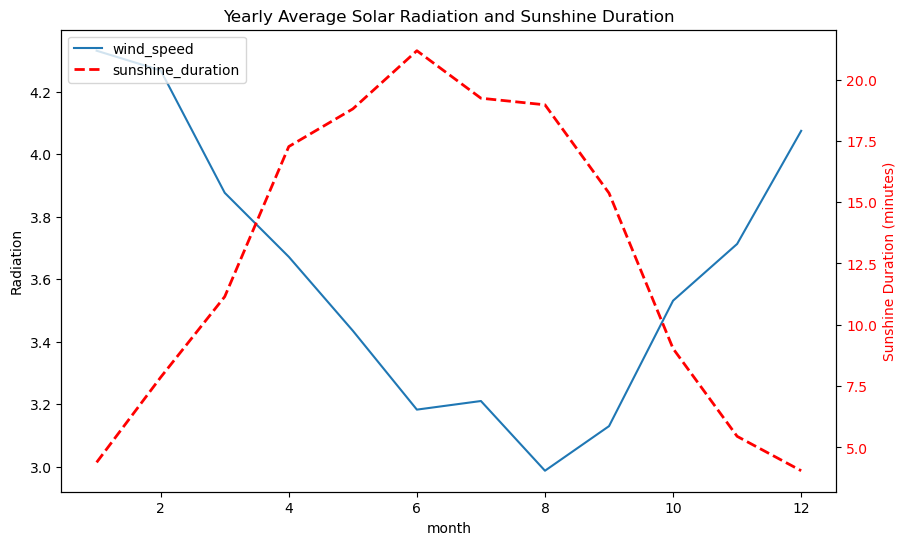

In [36]:
import matplotlib.pyplot as plt

month = eda_df.groupby("month")[
    [
        "wind_speed",
        "sunshine_duration"
    ]
].mean()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Radiation variables
month[
    [
       "wind_speed"
    ]
].plot(ax=ax1)

ax1.set_ylabel("Radiation")
ax1.set_title("Yearly Average Solar Radiation and Sunshine Duration")

# Sunshine duration on secondary axis (red)
ax2 = ax1.twinx()
month["sunshine_duration"].plot(
    ax=ax2,
    color="red",
    linestyle="--",
    linewidth=2,
    label="sunshine_duration"
)

ax2.set_ylabel("Sunshine Duration (minutes)", color="red")
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.show()

In [37]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98580 entries, 0 to 98579
Data columns (total 41 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   datetime                             98580 non-null  datetime64[ns]
 1   generation_biomass_mwh               98580 non-null  float64       
 2   generation_hydropower_mwh            98580 non-null  float64       
 3   generation_wind_offshore_mwh         98580 non-null  float64       
 4   generation_wind_onshore_mwh          98580 non-null  float64       
 5   generation_photovoltaics_mwh         98580 non-null  float64       
 6   generation_other_renewable_mwh       98557 non-null  float64       
 7   generation_nuclear_mwh               79587 non-null  float64       
 8   generation_lignite_mwh               98580 non-null  float64       
 9   generation_hard_coal_mwh             98580 non-null  float64       
 10  generation

month
1     61027.532919
2     61219.141450
3     57966.472054
4     54108.913817
5     52256.275307
6     52597.422923
7     52791.326045
8     51935.737168
9     53518.445982
10    55604.095830
11    59225.705062
12    57587.578864
Name: grid_load_mwh, dtype: float64


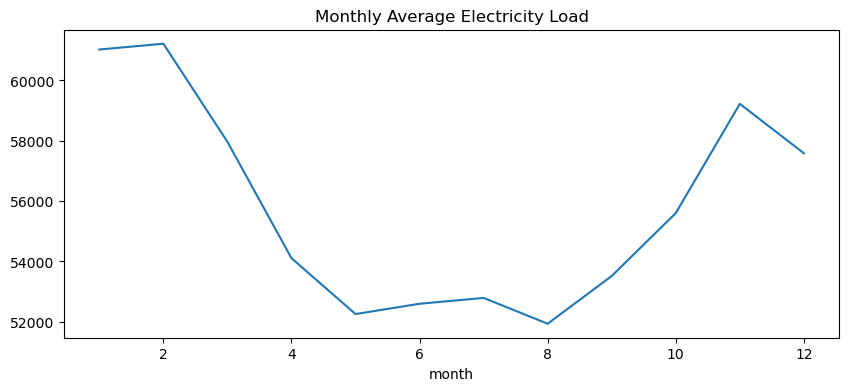

In [38]:
monthly_load = eda_df.groupby("month")[
    "grid_load_mwh"
].mean()

print(monthly_load)

monthly_load.plot(figsize=(10,4))
plt.title("Monthly Average Electricity Load")
plt.show()

# Correlation Matrix


In [39]:
corr_matrix = eda_df.corr(numeric_only=True)

print(corr_matrix.shape)
corr_matrix.head(40)

(40, 40)


,generation_biomass_mwh,generation_hydropower_mwh,generation_wind_offshore_mwh,generation_wind_onshore_mwh,generation_photovoltaics_mwh,generation_other_renewable_mwh,generation_nuclear_mwh,generation_lignite_mwh,generation_hard_coal_mwh,generation_fossil_gas_mwh,...,capacity_fossil_gas_mw,price_eur_per_mwh,year,hour,month,dayofweek,renewable_generation,conventional_generation,total_generation,total_capacity
generation_biomass_mwh,1.000000,-0.077304,0.125259,0.092931,-0.312029,0.688930,0.189593,0.299484,0.256507,0.269432,...,-0.304645,0.003421,-0.230890,0.180278,-0.149773,0.016725,-0.110474,0.393484,0.288818,-0.259929
generation_hydropower_mwh,-0.077304,1.000000,-0.255771,-0.273786,0.126938,-0.148543,-0.000927,-0.032467,-0.148550,-0.105805,...,0.056855,-0.149902,-0.109293,0.066993,0.025773,-0.066912,-0.118467,-0.078897,-0.204752,-0.104776
generation_wind_offshore_mwh,0.125259,-0.255771,1.000000,0.632409,-0.155422,0.099534,-0.200355,-0.371198,-0.299083,0.132393,...,0.133493,-0.016025,0.336230,0.006134,0.018981,0.011868,0.507173,-0.318661,0.202293,0.317230
generation_wind_onshore_mwh,0.092931,-0.273786,0.632409,1.000000,-0.185603,0.068026,-0.161630,-0.450978,-0.339591,-0.085989,...,0.080880,-0.170787,0.192266,0.009248,-0.057203,0.000298,0.699919,-0.384463,0.335979,0.182026
generation_photovoltaics_mwh,-0.312029,0.126938,-0.155422,-0.185603,1.000000,-0.240814,-0.153820,-0.254912,-0.181870,-0.149143,...,0.101297,-0.075447,0.142809,0.096893,-0.039922,0.001042,0.560827,-0.286252,0.291613,0.140569
generation_other_renewable_mwh,0.688930,-0.148543,0.099534,0.068026,-0.240814,1.000000,0.196432,0.342555,0.280487,0.176448,...,-0.400446,-0.117505,-0.314571,0.008563,-0.128226,-0.011586,-0.091378,0.389406,0.304521,-0.372713
generation_nuclear_mwh,0.189593,-0.000927,-0.200355,-0.161630,-0.153820,0.196432,1.000000,0.505455,0.309540,-0.205225,...,0.064585,-0.397618,-0.807237,0.002809,0.026710,-0.014900,-0.254679,0.580883,0.313116,-0.824311
generation_lignite_mwh,0.299484,-0.032467,-0.371198,-0.450978,-0.254912,0.342555,0.505455,1.000000,0.730872,0.039824,...,-0.413609,0.078389,-0.625290,0.062451,0.021215,-0.162597,-0.570006,0.876420,0.305013,-0.596859
generation_hard_coal_mwh,0.256507,-0.148550,-0.299083,-0.339591,-0.181870,0.280487,0.309540,0.730872,1.000000,0.173731,...,-0.317778,0.191203,-0.437191,0.132369,-0.010710,-0.256308,-0.428307,0.880767,0.457448,-0.423542
generation_fossil_gas_mwh,0.269432,-0.105805,0.132393,-0.085989,-0.149143,0.176448,-0.205225,0.039824,0.173731,1.000000,...,0.191520,0.336981,0.468949,0.114891,-0.061922,-0.209223,-0.147447,0.252521,0.105413,0.440517


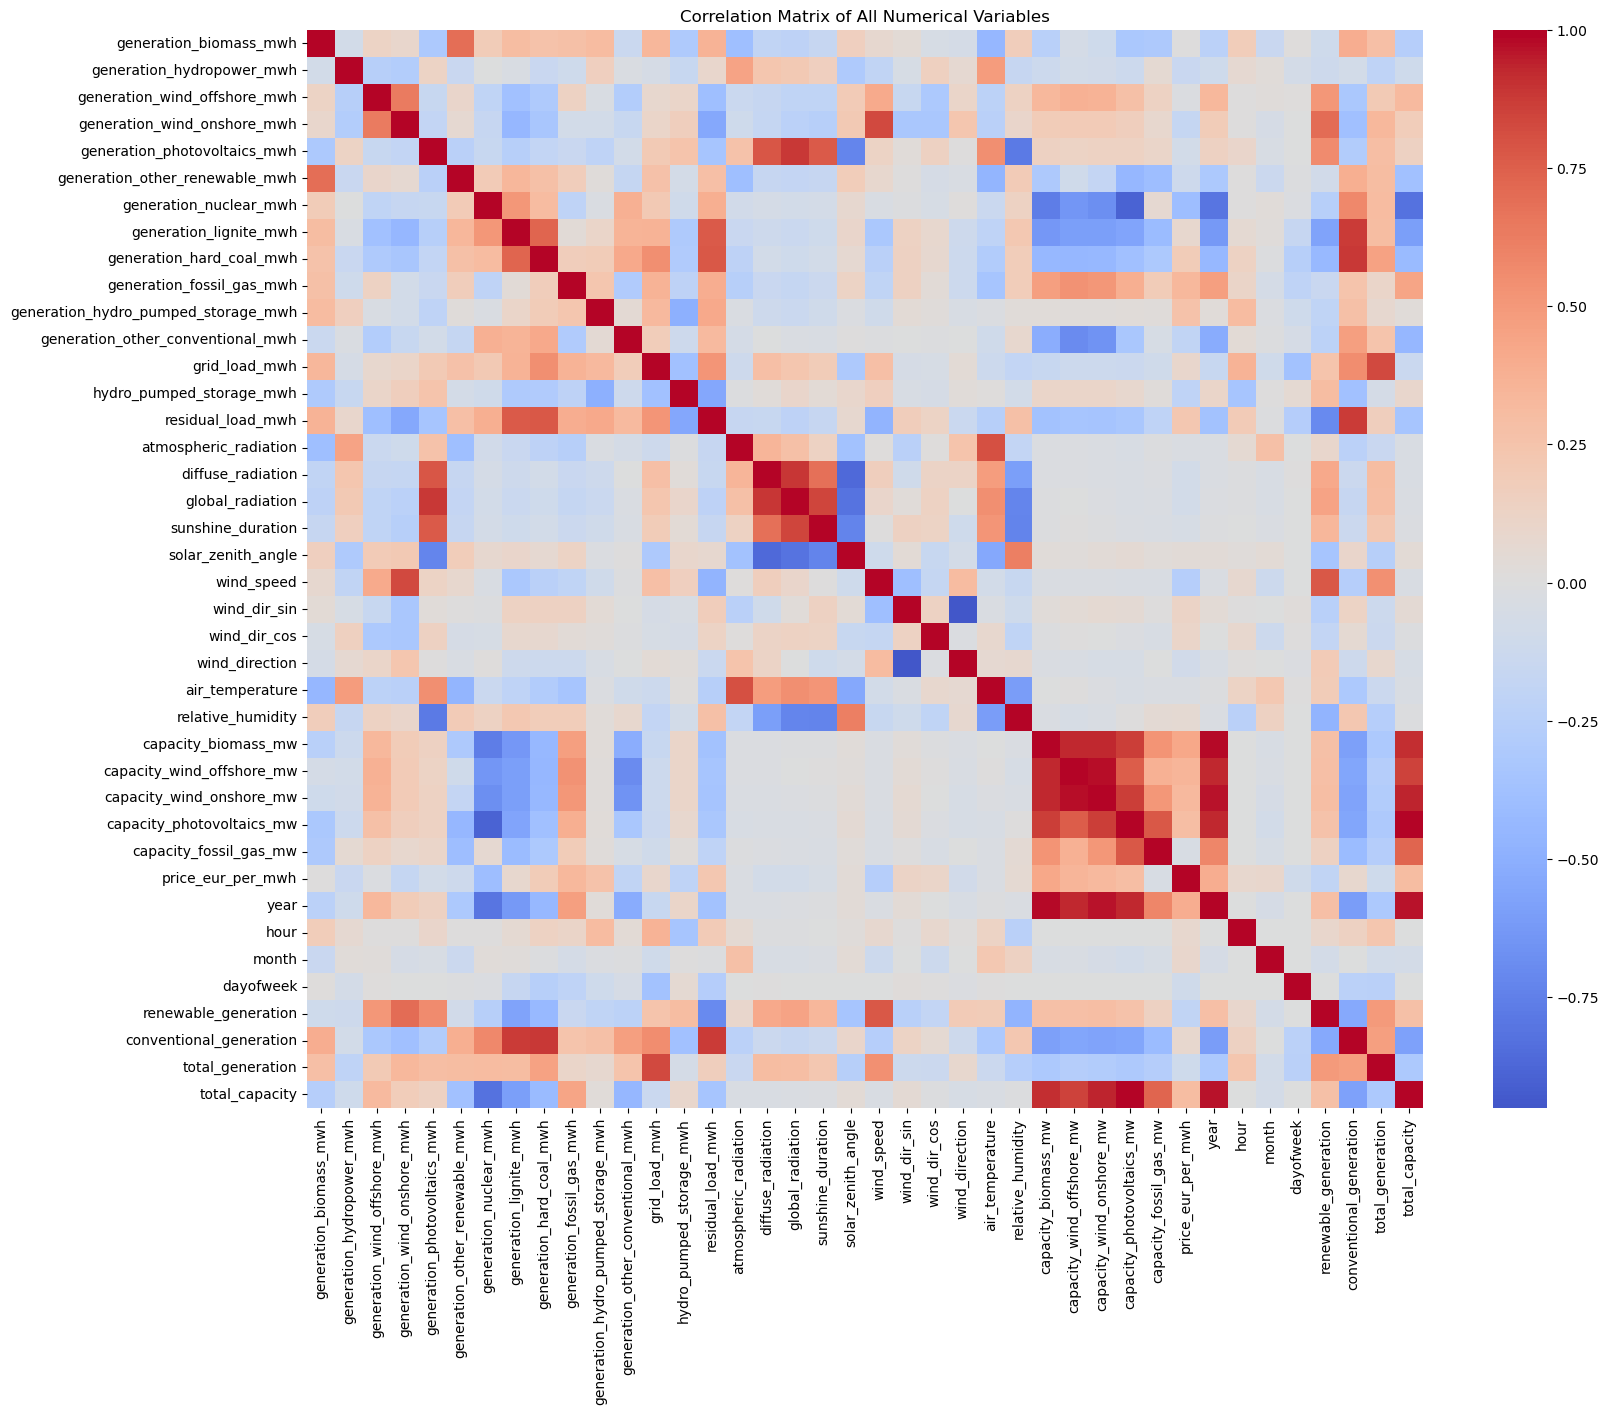

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of All Numerical Variables")
plt.show()

In [41]:
solar_corr = (
    corr_matrix["generation_photovoltaics_mwh"]
    .sort_values(ascending=False)
)

print(solar_corr)

generation_photovoltaics_mwh           1.000000
global_radiation                       0.884974
diffuse_radiation                      0.781884
sunshine_duration                      0.768928
renewable_generation                   0.560827
air_temperature                        0.544517
total_generation                       0.291613
atmospheric_radiation                  0.260010
hydro_pumped_storage_mwh               0.246496
grid_load_mwh                          0.205541
year                                   0.142809
wind_dir_cos                           0.140988
total_capacity                         0.140569
capacity_biomass_mw                    0.139269
capacity_photovoltaics_mw              0.137550
capacity_wind_onshore_mw               0.131649
wind_speed                             0.131237
generation_hydropower_mwh              0.126938
capacity_wind_offshore_mw              0.125745
capacity_fossil_gas_mw                 0.101297
hour                                   0

In [42]:
wind_on_corr = (
    corr_matrix["generation_wind_onshore_mwh"]
    .sort_values(ascending=False)
)

print(wind_on_corr)

generation_wind_onshore_mwh            1.000000
wind_speed                             0.829451
renewable_generation                   0.699919
generation_wind_offshore_mwh           0.632409
total_generation                       0.335979
wind_direction                         0.232578
solar_zenith_angle                     0.215239
capacity_wind_onshore_mw               0.198330
capacity_wind_offshore_mw              0.196346
year                                   0.192266
capacity_biomass_mw                    0.188063
total_capacity                         0.182026
capacity_photovoltaics_mw              0.167658
hydro_pumped_storage_mwh               0.163127
grid_load_mwh                          0.105490
relative_humidity                      0.101052
generation_biomass_mwh                 0.092931
capacity_fossil_gas_mw                 0.080880
generation_other_renewable_mwh         0.068026
hour                                   0.009248
dayofweek                              0

In [43]:
wind_off_corr = (
    corr_matrix["generation_wind_offshore_mwh"]
    .sort_values(ascending=False)
)

print(wind_off_corr)

generation_wind_offshore_mwh           1.000000
generation_wind_onshore_mwh            0.632409
renewable_generation                   0.507173
wind_speed                             0.412200
capacity_wind_offshore_mw              0.371475
capacity_wind_onshore_mw               0.365322
year                                   0.336230
capacity_biomass_mw                    0.332703
total_capacity                         0.317230
capacity_photovoltaics_mw              0.280892
total_generation                       0.202293
solar_zenith_angle                     0.199127
capacity_fossil_gas_mw                 0.133493
relative_humidity                      0.133067
generation_fossil_gas_mwh              0.132393
generation_biomass_mwh                 0.125259
hydro_pumped_storage_mwh               0.108041
wind_direction                         0.102567
generation_other_renewable_mwh         0.099534
grid_load_mwh                          0.080412
month                                  0

# VIF Analysis

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

vif_features = [

    "atmospheric_radiation",
    "diffuse_radiation",
    "global_radiation",
    "sunshine_duration",
    "solar_zenith_angle",

    "wind_speed",
    "wind_dir_sin",
    "wind_dir_cos",

    "air_temperature",
    "relative_humidity",

    "grid_load_mwh",
    "hydro_pumped_storage_mwh",
    "price_eur_per_mwh"
]

X = eda_df[vif_features].copy()

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_df = vif_df.sort_values("VIF", ascending=False)

print(vif_df)

                    Variable         VIF
0      atmospheric_radiation  428.549328
9          relative_humidity  143.753362
10             grid_load_mwh   52.298849
4         solar_zenith_angle   38.128618
8            air_temperature   30.146626
2           global_radiation   15.126275
5                 wind_speed   12.974062
1          diffuse_radiation   12.069445
3          sunshine_duration    6.379156
11  hydro_pumped_storage_mwh    2.571916
12         price_eur_per_mwh    2.089028
6               wind_dir_sin    1.477326
7               wind_dir_cos    1.270352


# Solar Generation Drivers Plots

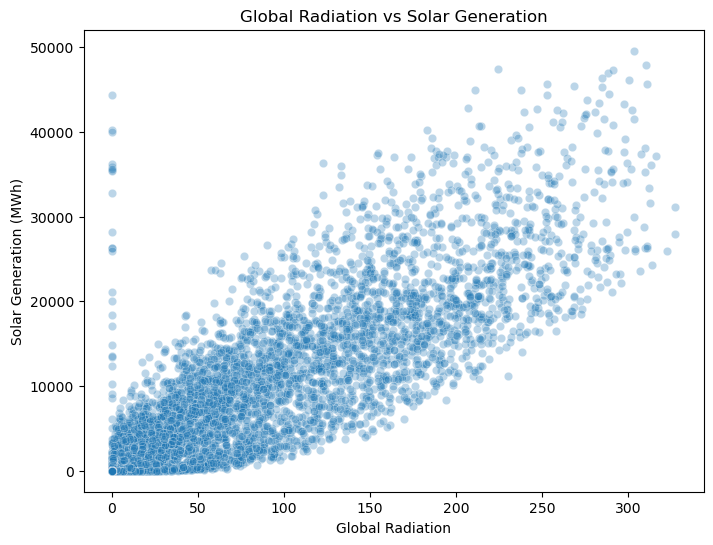

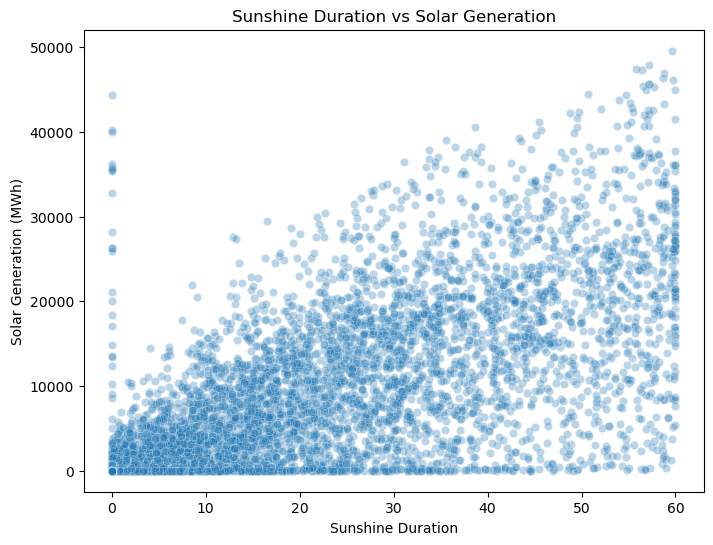

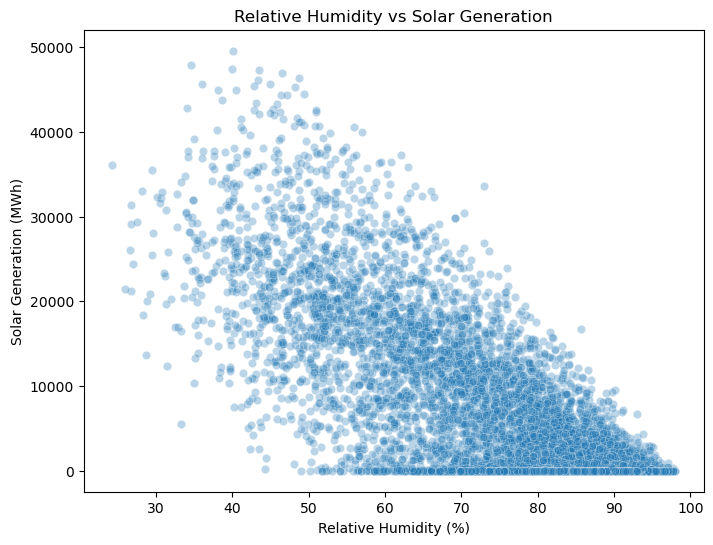

In [45]:
#Plot 1: Global Radiation vs Solar Generation
import seaborn as sns
import matplotlib.pyplot as plt

sample_df = eda_df.sample(
    n=min(10000, len(eda_df)),
    random_state=42
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample_df,
    x="global_radiation",
    y="generation_photovoltaics_mwh",
    alpha=0.3
)

plt.title("Global Radiation vs Solar Generation")
plt.xlabel("Global Radiation")
plt.ylabel("Solar Generation (MWh)")
plt.show()
# Plot 2: Sunshine Duration vs Solar Generation
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample_df,
    x="sunshine_duration",
    y="generation_photovoltaics_mwh",
    alpha=0.3
)

plt.title("Sunshine Duration vs Solar Generation")
plt.xlabel("Sunshine Duration")
plt.ylabel("Solar Generation (MWh)")
plt.show()

# Plot 3: Relative Humidity vs Solar Generation
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample_df,
    x="relative_humidity",
    y="generation_photovoltaics_mwh",
    alpha=0.3
)

plt.title("Relative Humidity vs Solar Generation")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Solar Generation (MWh)")
plt.show()

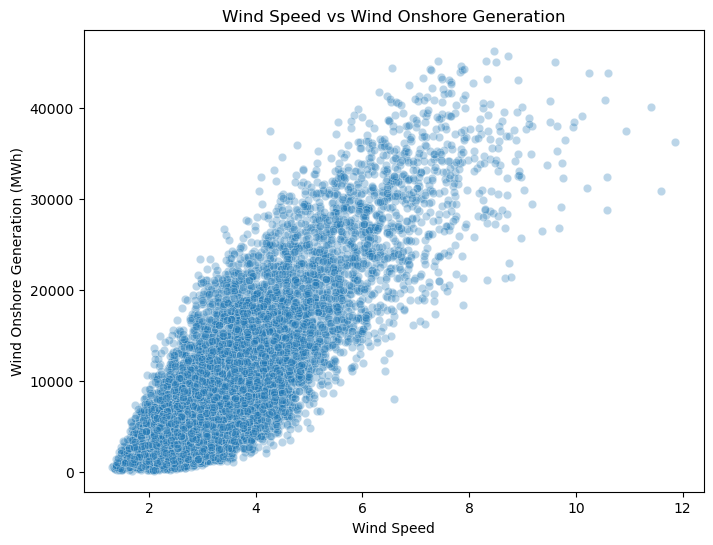

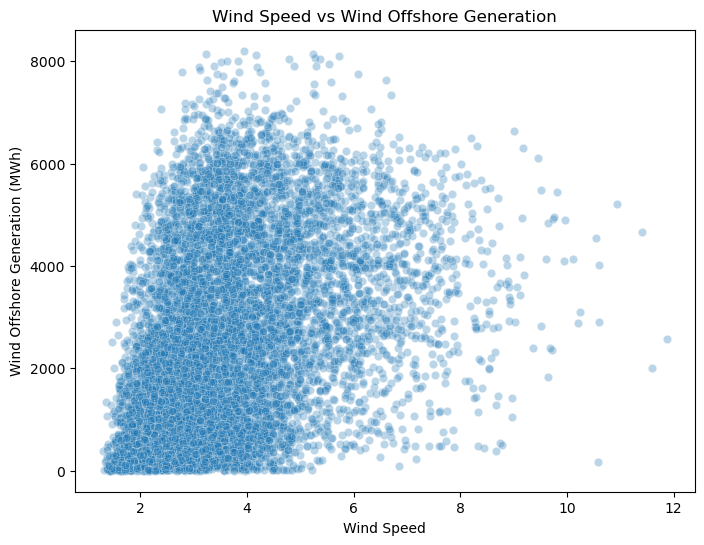

In [46]:
#Plot 4: Wind Speed vs Wind Onshore Generation
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample_df,
    x="wind_speed",
    y="generation_wind_onshore_mwh",
    alpha=0.3
)

plt.title("Wind Speed vs Wind Onshore Generation")
plt.xlabel("Wind Speed")
plt.ylabel("Wind Onshore Generation (MWh)")
plt.show()


#Plot 5: Wind Speed vs Wind Offshore Generation
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample_df,
    x="wind_speed",
    y="generation_wind_offshore_mwh",
    alpha=0.3
)

plt.title("Wind Speed vs Wind Offshore Generation")
plt.xlabel("Wind Speed")
plt.ylabel("Wind Offshore Generation (MWh)")
plt.show()

# Capacity Development Analysis

In [47]:
capacity_cols = [
    "capacity_biomass_mw",
    "capacity_wind_offshore_mw",
    "capacity_wind_onshore_mw",
    "capacity_photovoltaics_mw",
    "capacity_fossil_gas_mw"
]

capacity_yearly = (
    eda_df.groupby("year")[capacity_cols]
    .mean()
)

capacity_yearly

,capacity_biomass_mw,capacity_wind_offshore_mw,capacity_wind_onshore_mw,capacity_photovoltaics_mw,capacity_fossil_gas_mw
year,,,,,
2015,6808.0,3300.0,37701.0,37271.0,31734.0
2016,6815.0,4100.0,41168.0,38686.0,32398.0
2017,7080.0,5400.0,47042.0,40834.0,32627.0
2018,7073.0,6600.0,51633.0,42804.0,30232.0
2019,7720.0,7700.0,52394.0,44036.0,31664.0
2020,7833.0,7800.0,53553.0,47754.0,31712.0
2021,8204.0,7900.0,54345.0,50410.0,31942.0
2022,8332.0,8100.0,55289.0,57744.0,30553.0
2023,8467.0,8400.0,57590.0,63066.0,31808.0


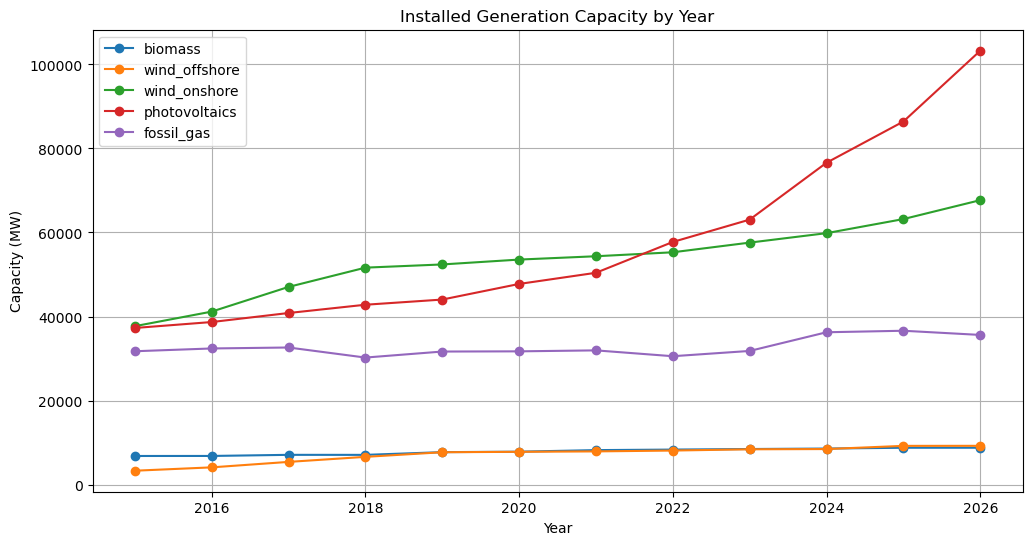

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for col in capacity_yearly.columns:
    plt.plot(
        capacity_yearly.index,
        capacity_yearly[col],
        marker="o",
        label=col.replace("capacity_", "").replace("_mw","")
    )

plt.title("Installed Generation Capacity by Year")
plt.xlabel("Year")
plt.ylabel("Capacity (MW)")
plt.legend()
plt.grid(True)
plt.show()

# Demand and Market Analysis

In [49]:
eda_df[
    [
        "grid_load_mwh",
        "residual_load_mwh",
        "price_eur_per_mwh"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
grid_load_mwh,98580.0,55882.754970,9943.769057,30902.75,47752.2150,55602.00,63963.705,81319.50
residual_load_mwh,98580.0,37019.061716,13701.618785,-8443.14,28193.0125,37705.63,46469.500,76034.38
price_eur_per_mwh,98580.0,73.608086,80.261359,-500.00,30.1475,46.81,92.500,936.28


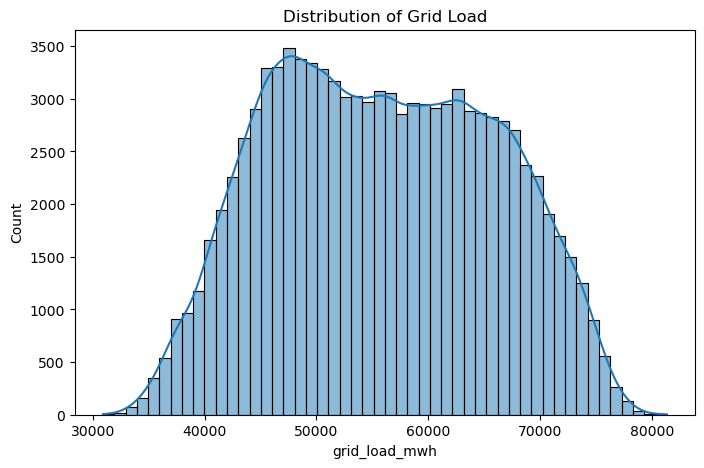

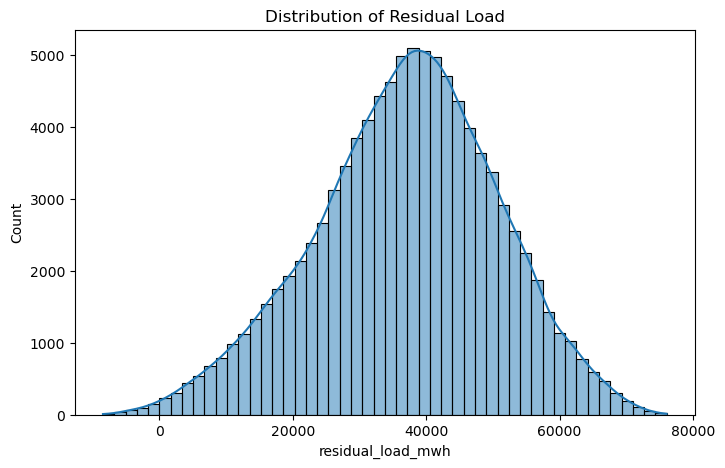

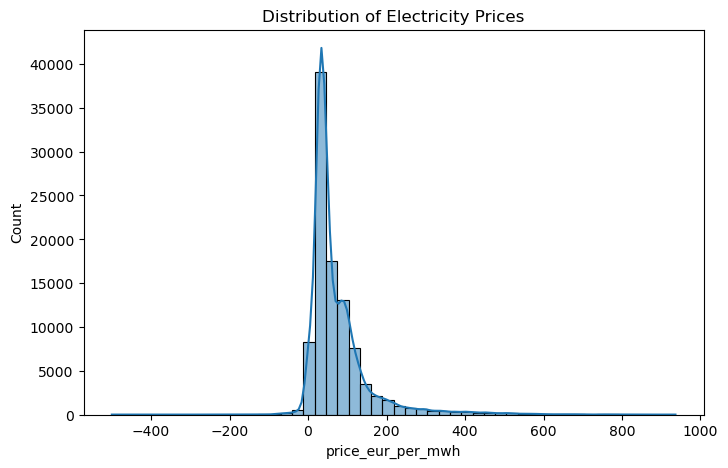

In [50]:
# Grid Load
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    eda_df["grid_load_mwh"],
    bins=50,
    kde=True
)

plt.title("Distribution of Grid Load")
plt.show()

#Residual Load
plt.figure(figsize=(8,5))

sns.histplot(
    eda_df["residual_load_mwh"],
    bins=50,
    kde=True
)

plt.title("Distribution of Residual Load")
plt.show()

#Electricity Price
plt.figure(figsize=(8,5))

sns.histplot(
    eda_df["price_eur_per_mwh"],
    bins=50,
    kde=True
)

plt.title("Distribution of Electricity Prices")
plt.show()

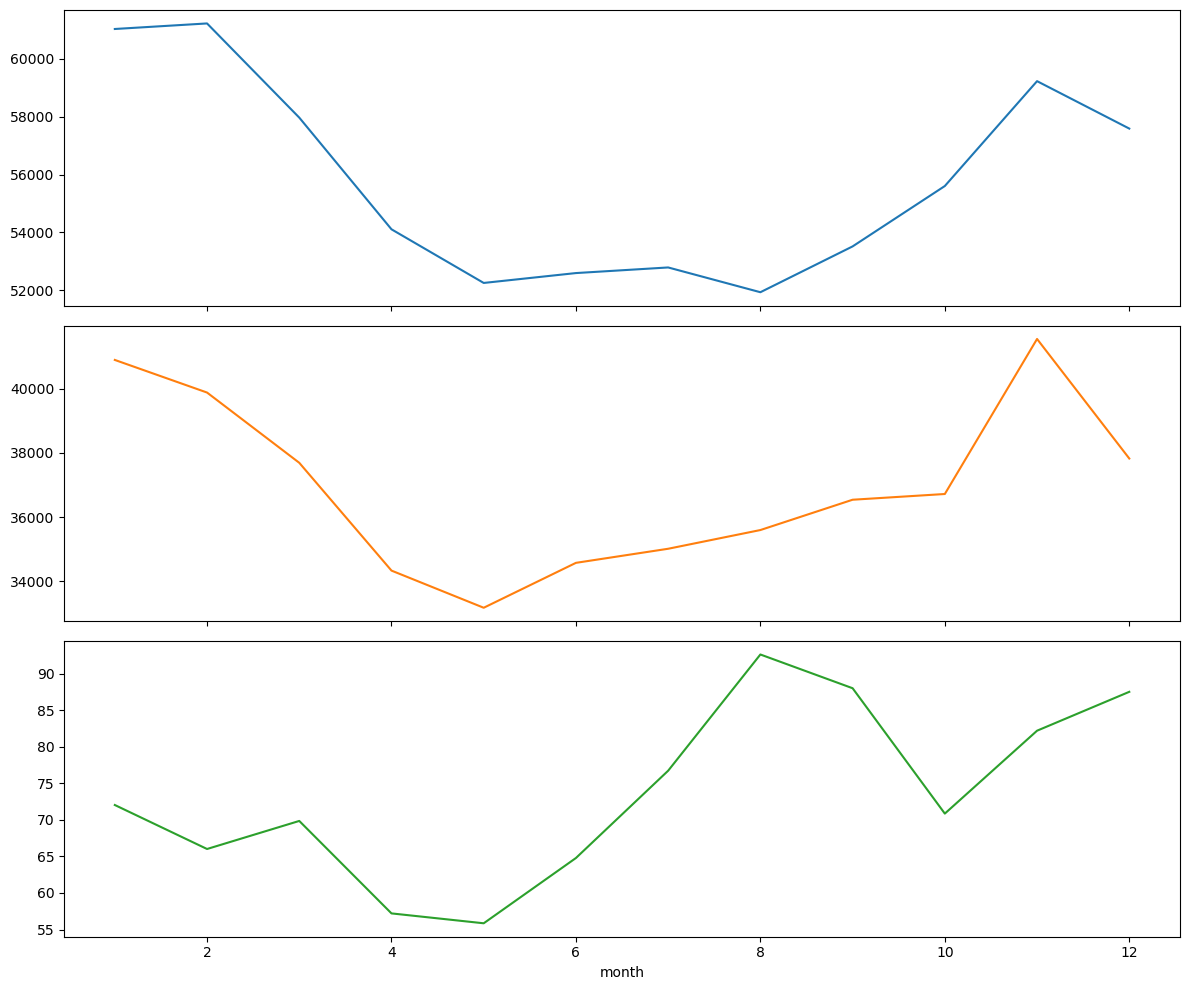

In [51]:
# monthly patterns
monthly_market = (
    eda_df.groupby("month")[
        [
            "grid_load_mwh",
            "residual_load_mwh",
            "price_eur_per_mwh"
        ]
    ]
    .mean()
)

monthly_market


monthly_market.plot(
    subplots=True,
    figsize=(12,10),
    legend=False
)

plt.tight_layout()
plt.show()

# STL Decomposition for Solar Generation

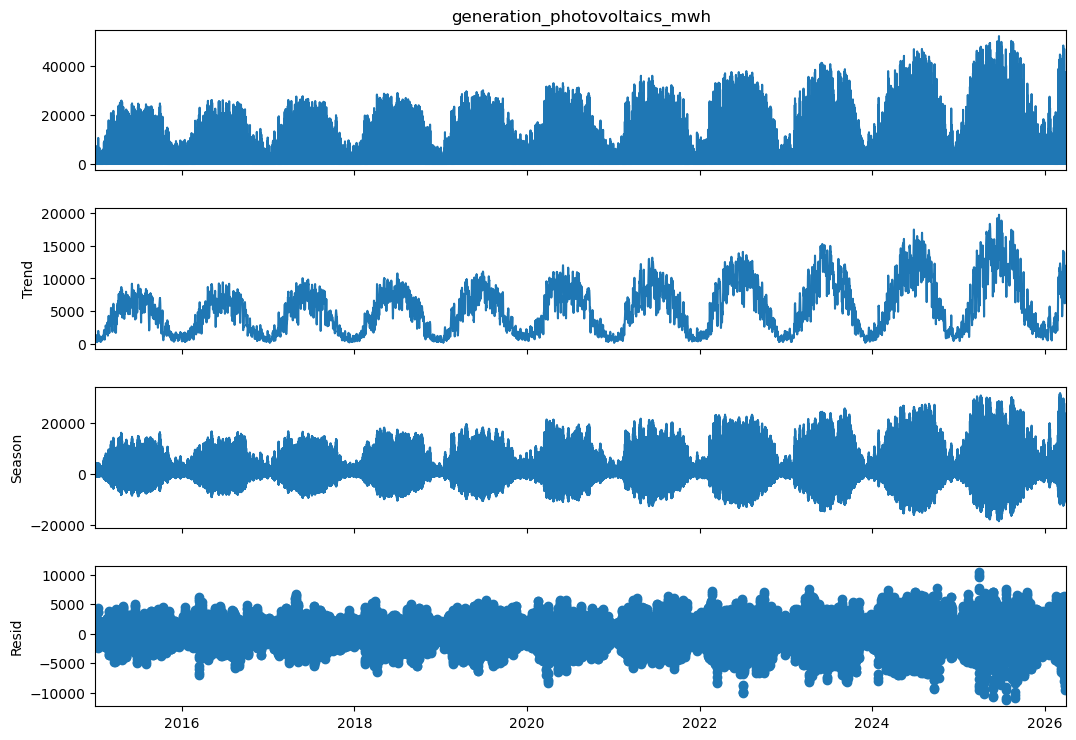

In [52]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

solar_series = (
    eda_df
    .set_index("datetime")
    ["generation_photovoltaics_mwh"]
)

stl = STL(
    solar_series,
    period=24
)

result = stl.fit()

fig = result.plot()
fig.set_size_inches(12,8)

plt.show()

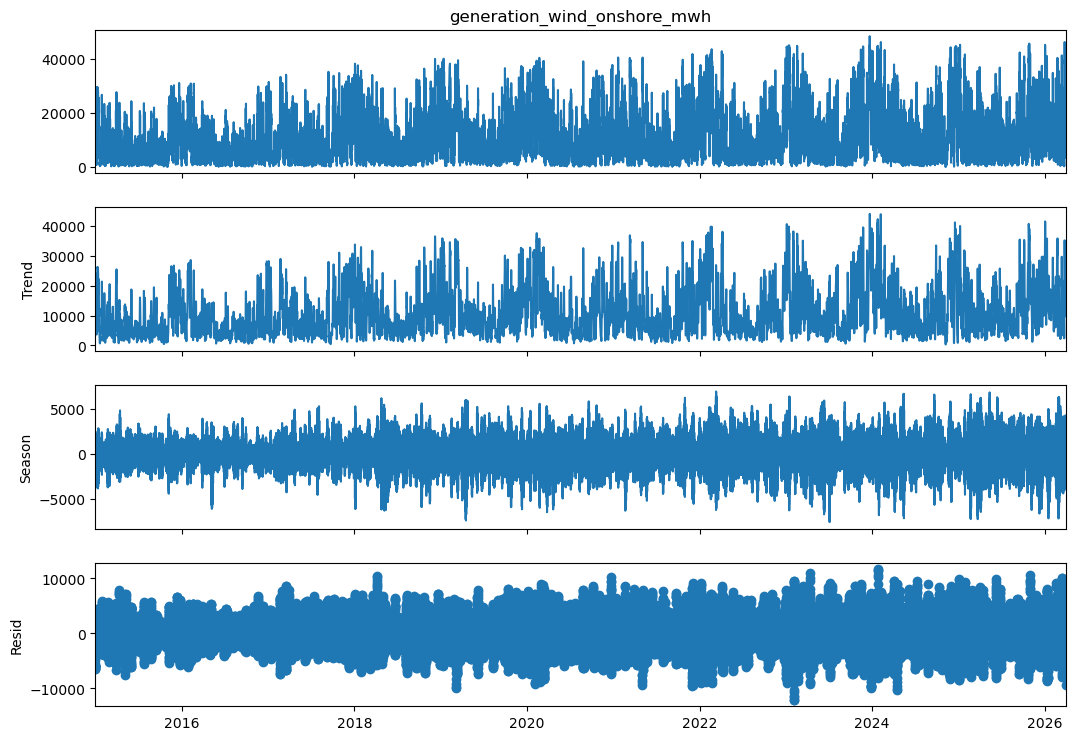

In [53]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

wind_onshore_series = (
    eda_df
    .set_index("datetime")
    ["generation_wind_onshore_mwh"]
)

stl = STL(
    wind_onshore_series,
    period=24
)

result = stl.fit()

fig = result.plot()
fig.set_size_inches(12,8)

plt.show()

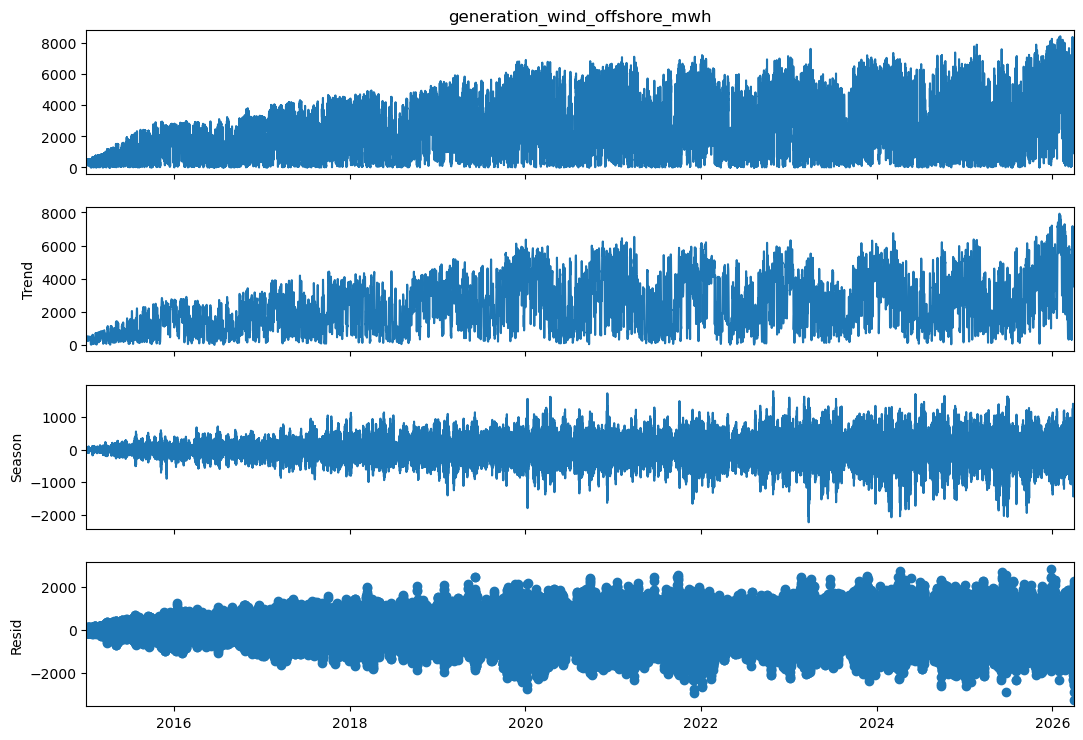

In [54]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

wind_offshore_series = (
    eda_df
    .set_index("datetime")
    ["generation_wind_offshore_mwh"]
)

stl = STL(
    wind_offshore_series,
    period=24
)

result = stl.fit()

fig = result.plot()
fig.set_size_inches(12,8)

plt.show()

In [55]:
import os

# Directory path
output_dir = "Data_Corpus/final"

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save CSV
output_file = os.path.join(output_dir, "eda_dataset_final.csv")

eda_df.to_csv(output_file, index=False)

print(f"File saved successfully: {output_file}")



if os.path.exists(output_file):
    print("File saved successfully.")
else:
    print("File was not saved.")

File saved successfully: Data_Corpus/final\eda_dataset_final.csv
File saved successfully.
